# Initialization

### Imports

In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import numpy as np
import tqdm as tqdm_package
from tqdm.notebook import tqdm
from scipy.integrate import odeint
from torch.nn.modules.normalization import LocalResponseNorm

from torch.func import jacrev, vmap

import neurodiffeq
from neurodiffeq import diff
from neurodiffeq.conditions import (
    IVP,
    DirichletBVP,
    DirichletBVP2D,
    BundleIVP,
    NoCondition,
    BundleDirichletBVP,
)

from neurodiffeq import diff

import copy as copy
import cmath as cmath

import json
from copy import deepcopy
from warnings import warn
import zipfile


from skfem import MeshLine, Basis, ElementLineP1, BilinearForm, asm, condense, solve
from skfem.helpers import grad

import seaborn as sns
from cycler import cycler
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D
from dataclasses import dataclass, field

from typing import Callable, Optional, Dict, Tuple

Array = np.ndarray

/Users/davyd/miniconda3/envs/pinns_regularization/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
from importlib import reload

sys.path.append("./src")

from importlib import reload

import helpers
import visualization
import numerical_solvers
import neurodiffeqq
import models
import mh_solver
import callbacks
import data_classes
import equation_setup

reload(helpers)
reload(visualization)
reload(numerical_solvers)
reload(neurodiffeqq)
reload(models)
reload(mh_solver)
reload(callbacks)
reload(data_classes)
reload(equation_setup)

from helpers import *
from visualization import *
from numerical_solvers import *
from neurodiffeqq import *
from models import *
from mh_solver import *
from callbacks import *
from data_classes import *
from equation_setup import *

### Package versions

In [3]:
package_versions = {
    "python": sys.version,
    "torch": get_version(torch),
    "numpy": get_version(np),
    "tqdm": get_version(tqdm_package),
    "scipy": get_version(__import__("scipy")),
    "neurodiffeq": get_version(neurodiffeq),
    "seaborn": get_version(sns),
    "cycler": get_version(__import__("cycler")),
    "matplotlib": get_version(__import__("matplotlib")),
}

with open("imported_packages_versions.txt", "w") as f:
    for k, v in package_versions.items():
        f.write(f"{k}: {v}\n")

In [4]:
save_reproducibility_snapshot()

### Google Drive connect

In [5]:
if is_colab():
    from google.colab import drive

    mount_path = "/content/drive"
    drive.mount(mount_path)

    dir_path = "/content/drive/MyDrive/Colab Notebooks/Diploma/D28"

    os.chdir(dir_path)

### Plots setup

In [6]:
set_paper_style()

### Random state generator

In [7]:
set_seed(42)

### Regularizations setup

In [8]:
regularization_values = build_regularization_values(powers=range(-7, 3), ks=(1,))

#

---

### Plots Creation

In [9]:
zip_path = "david_finall.zip"
extract_path = "final_model_states"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


#### Allen-Cahn

In [10]:
allen_cahn_spec = EquationSpec(
    name="allen-cahn",
    equation_factory=allen_cahn_equation,
    ic_fn=allen_cahn_ic,
    bc_left_builder=make_allen_cahn_bc_left,
    bc_right_builder=make_allen_cahn_bc_right,
    exact_fns_container=None,
    numerical_solution_func=solve_allen_cahn,
    equations_number=1,
    ib_conditions_size=1,
    seed=52,
)

register_equation(allen_cahn_spec)

allen_cahn_run = make_run_config(
    equation_name="allen-cahn",
    models_save_dir=f"./allen-cahn_loader",
    domain=DomainConfig(
        t_min=0.0,
        t_max=1.0,
        t_num=32,
        x_min=-1.0,
        x_max=1.0,
        x_num=64,
        param_min=0.0001,
        param_max=0.0001,
        param_num=1,
    ),
    network=NetworkConfig(
        body_units=(20, 20, 20, 20, 20, 20),
        head_units=(16, 16),
        basis_length=8,
        input_encoding="identity",
        use_bias=True,
        weights_init_method="default",
        small_normal_std=1e-2,
    ),
    optimizer=OptimizerConfig(
        mode="lbfgs",
        lbfgs_epochs=1,
        lbfgs_lr=0.5,
        lbfgs_max_iter=75,
    ),
    train=TrainConfig(
        epochs=0,
        save_period=100,
        regularization_period=1,
    ),
    eval_cfg=EvalConfig(
        dx=0.1,
        t_i=0.5,
        param_i=0.0001,
        convergence_value=1e-3,
        period=1,
    ),
    regularizations={None: [0.0]},
)

results_allen_cahn = run_experiment(allen_cahn_run)

/Users/davyd/miniconda3/envs/pinns_regularization/lib/python3.12/site-packages/neurodiffeq/solvers.py:197: RuntimeWarning: Setting n_batches_valid=0 will update lowest_loss and best_net with training loss instead of validation loss. This is a problem for <class 'torch.optim.lbfgs.LBFGS'> optimizer because it updates the parameters before the training loss computed. This leads to potentially worse solution in `best_net`!
  warnings.warn(f"Setting n_batches_valid=0 will update lowest_loss and best_net with training loss "


Training Progress: 100%|██████████| 1/1 [00:03<00:00,  3.34s/it]


In [11]:
local_head = 0
dt = 0.001
r_i = 0.0001
t_i = 0.5

x = torch.arange(
    -1.0, 1 + dt, dt, requires_grad=True, device=device if "device" in globals() else None
)
t_1d = torch.full_like(x, t_i, requires_grad=True, device=x.device)
r = torch.full_like(x, r_i, requires_grad=True, device=x.device)

_, _, u_ref_allen_cahn = solve_allen_cahn(r_i, 1e-4, t_i, 0, -1.0, 1.0, dt)

In [12]:
base = "./final_model_states/david_finall/allen-cahn_52"
allen_cahn_dirs = [d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]

allen-cahn_gPINN_lambda_1e-06


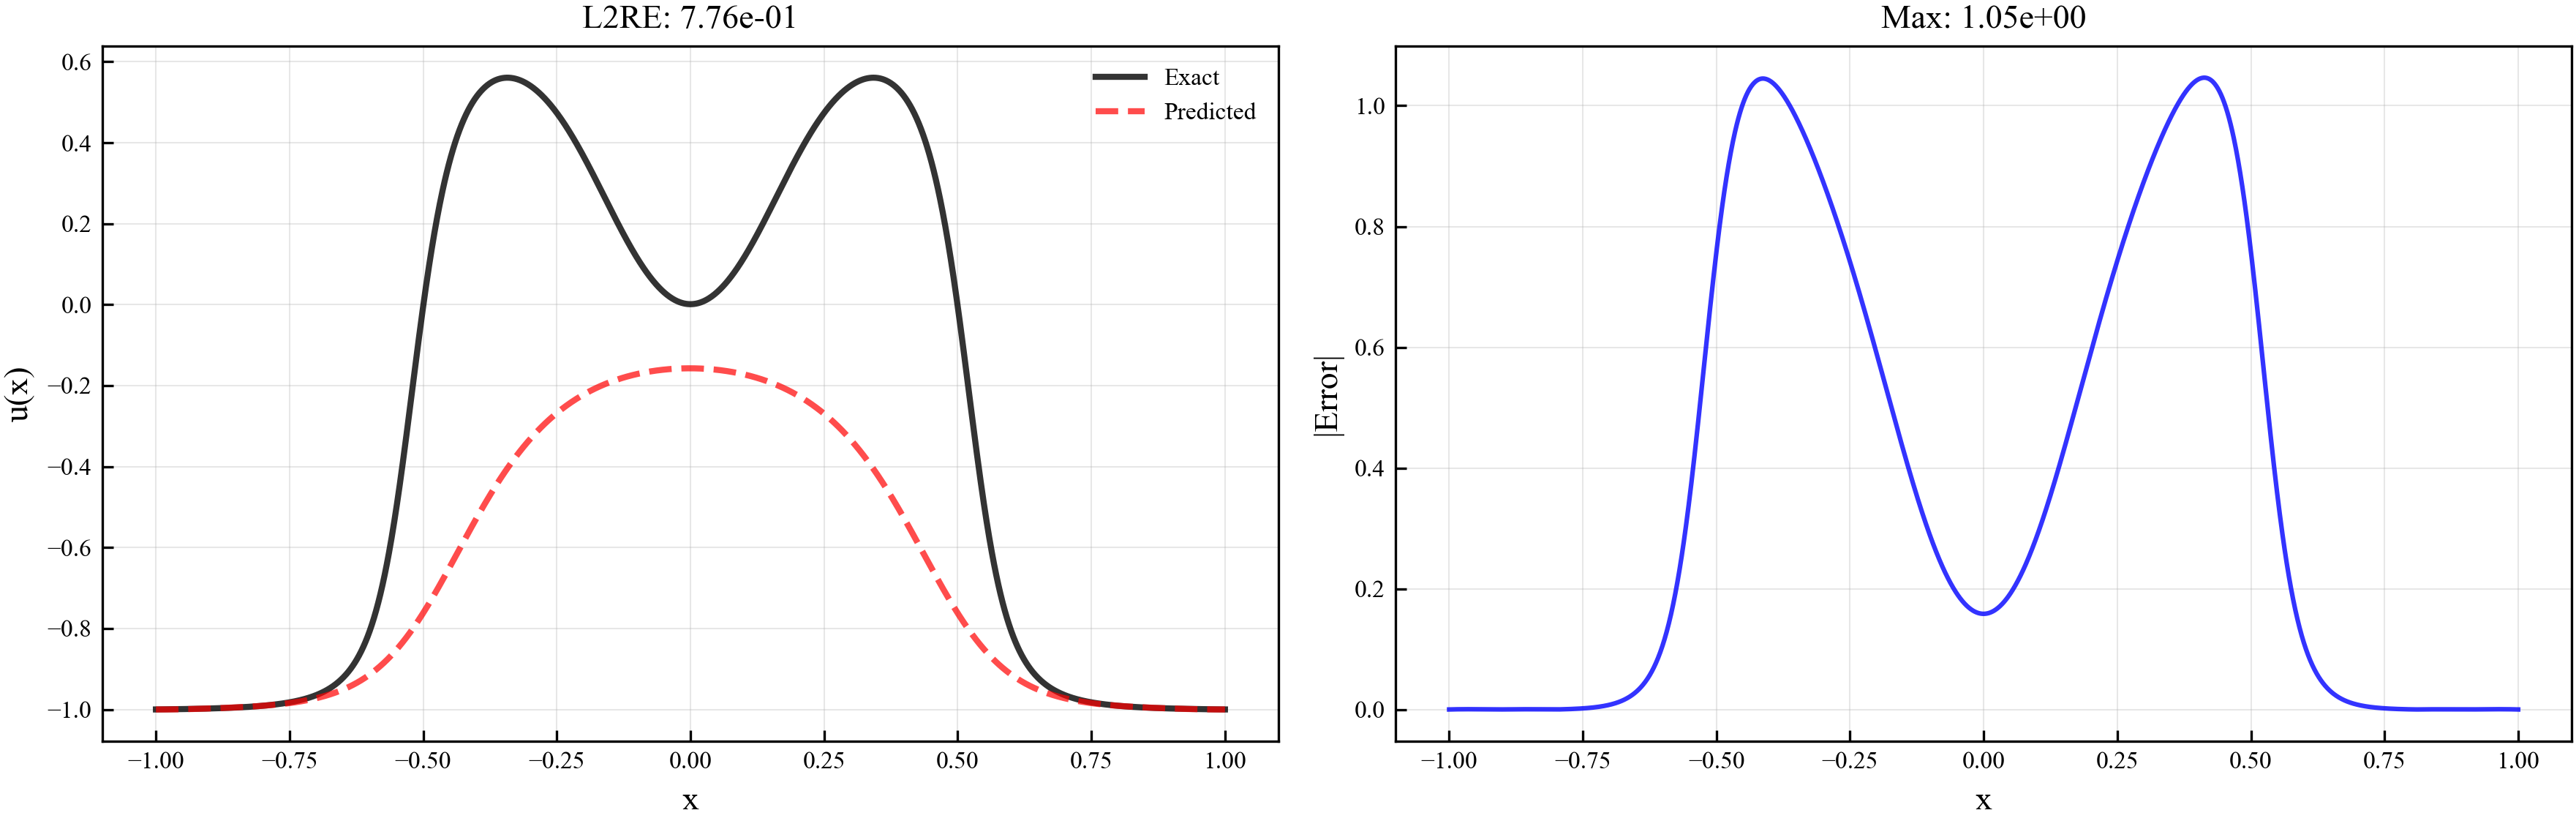

allen-cahn_J_lambda_1e-07


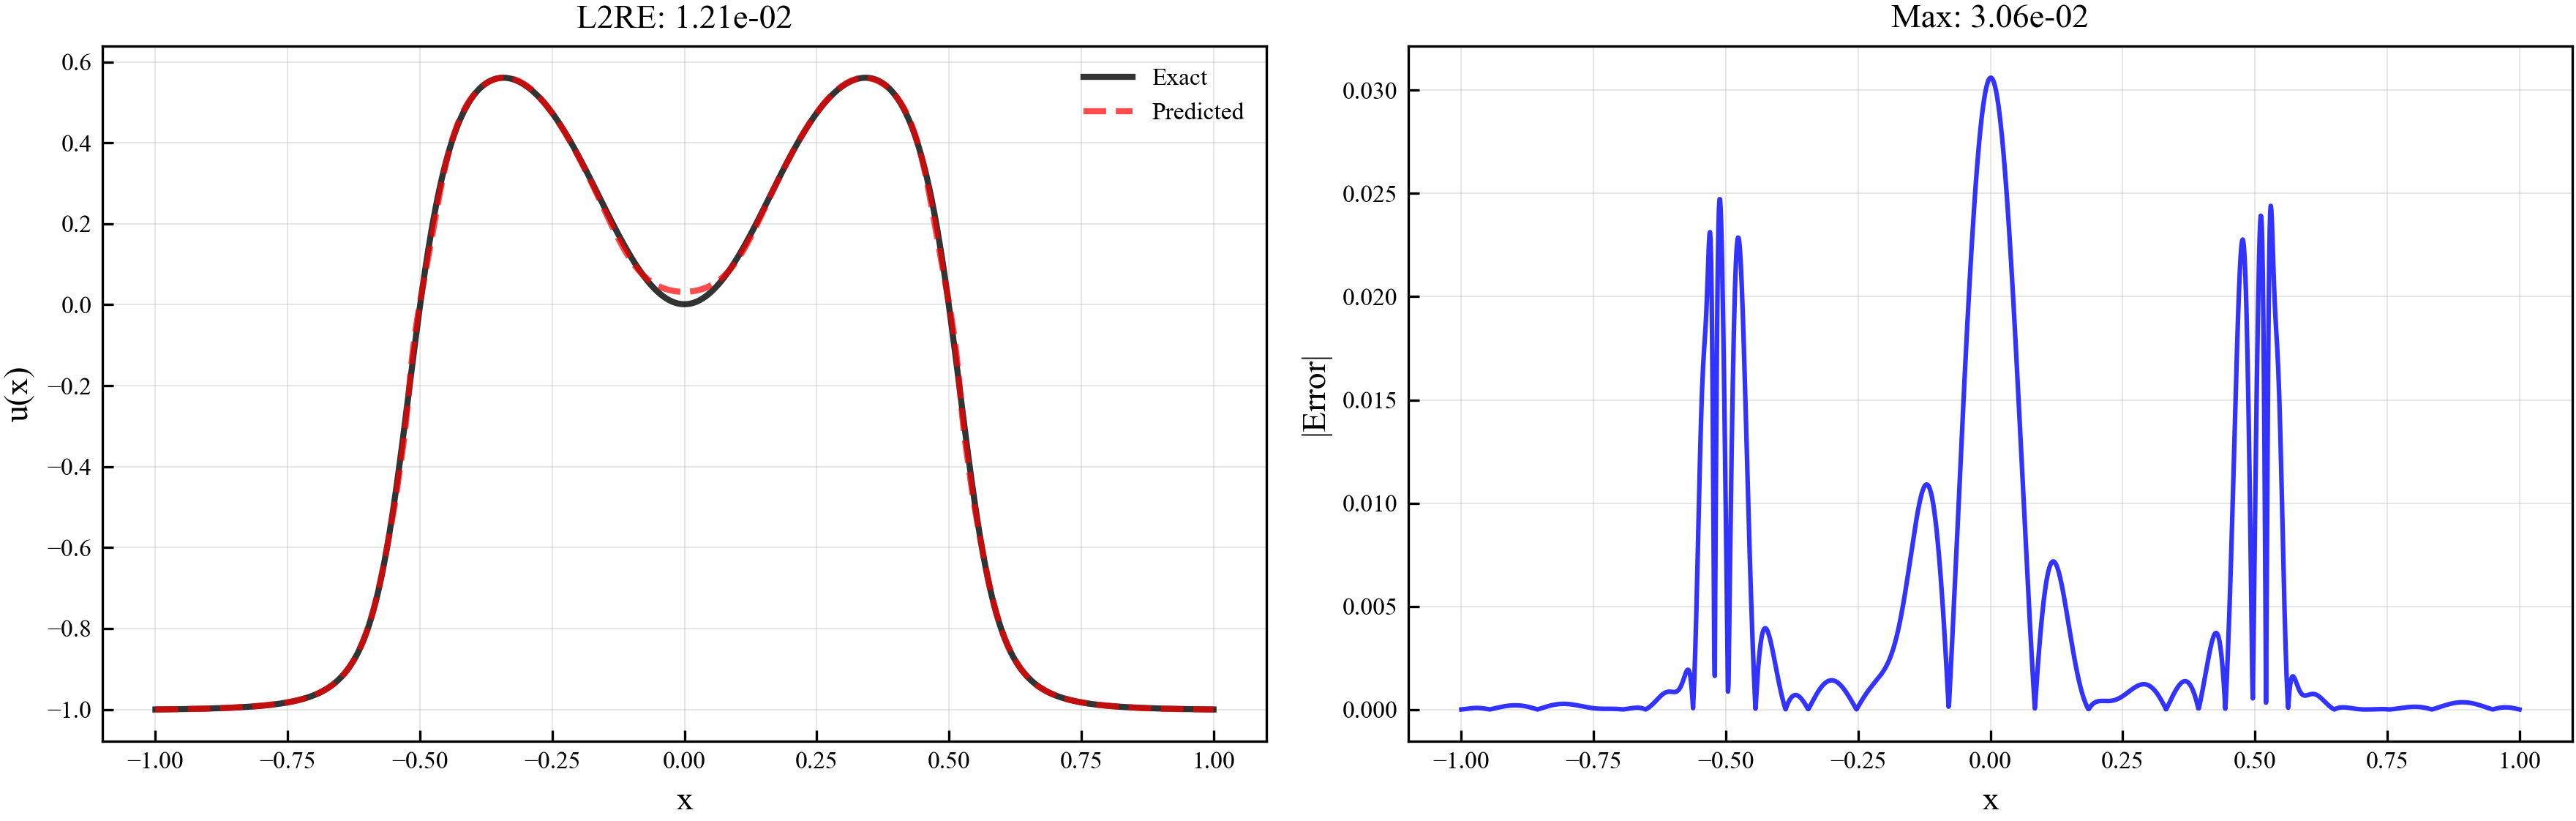

allen-cahn_L2_lambda_0.0001


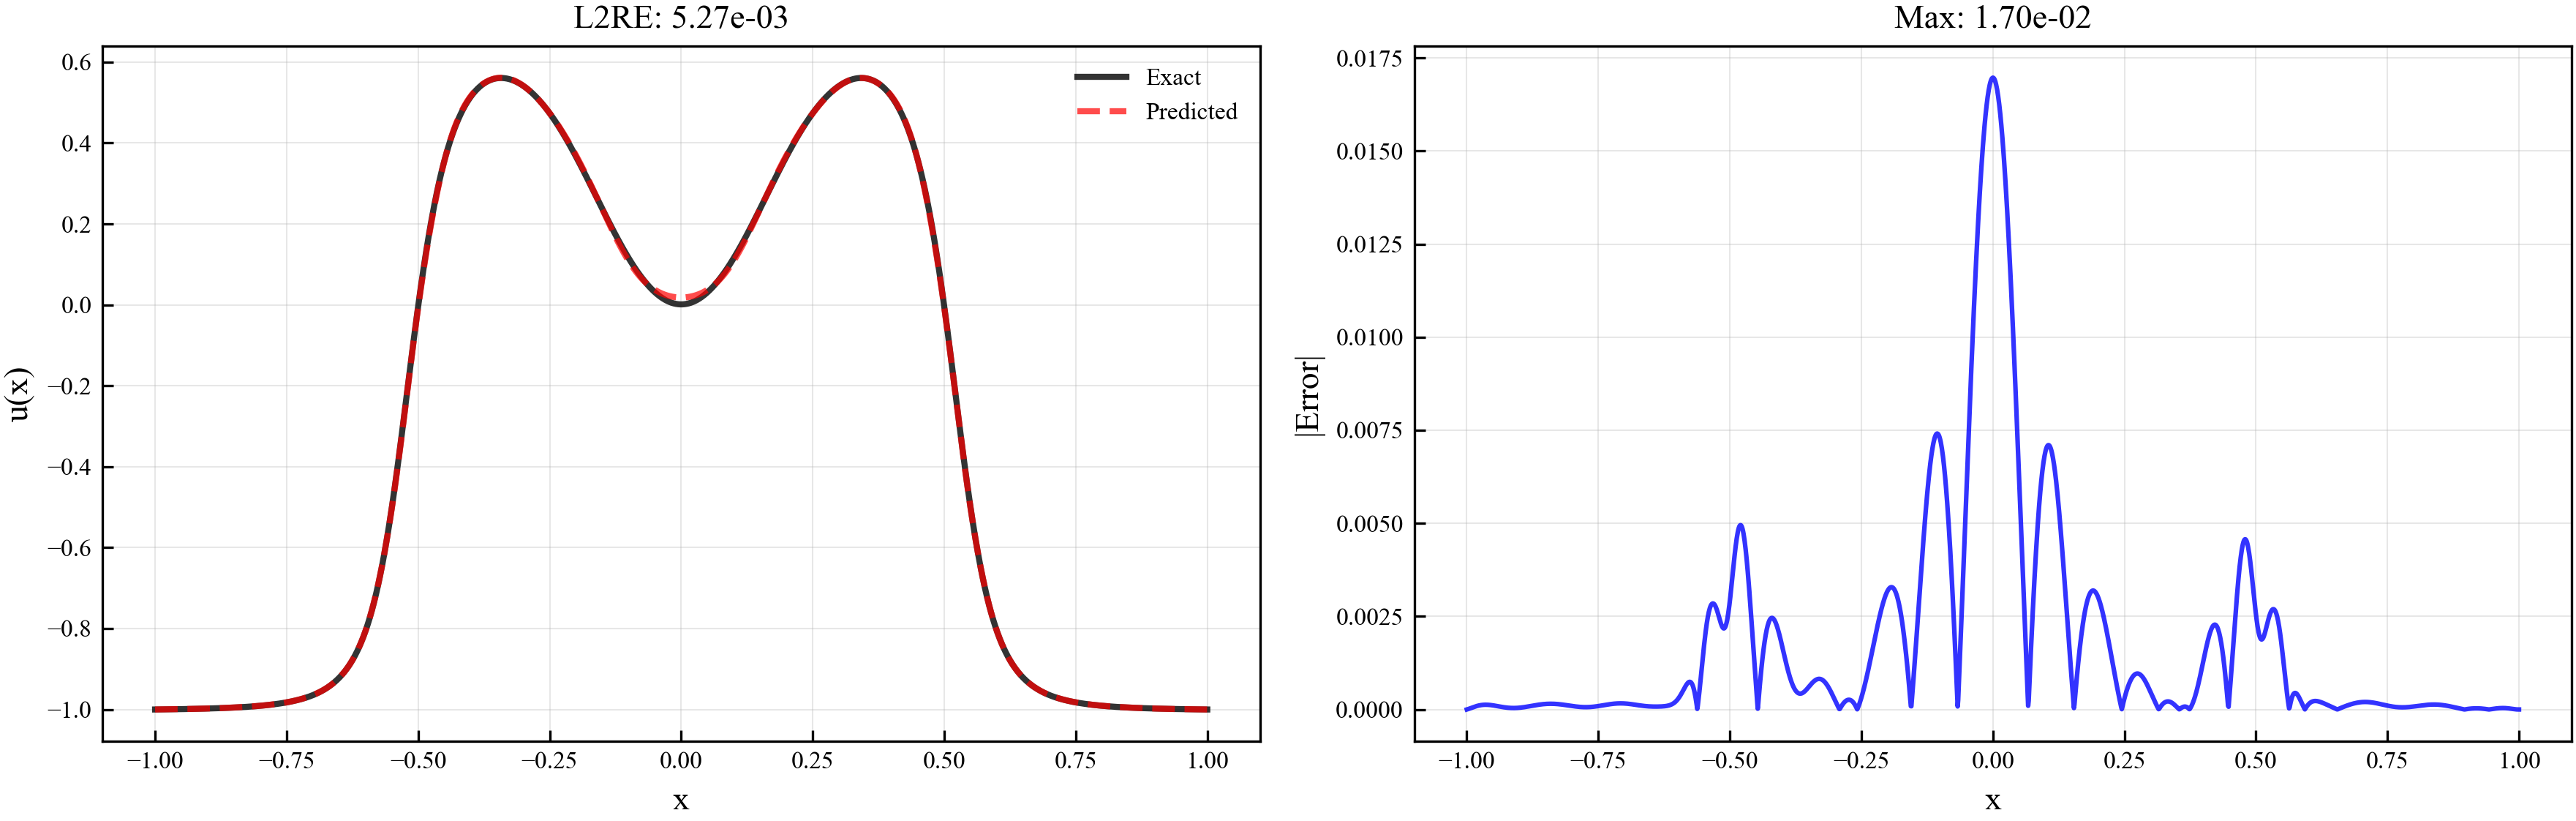

allen-cahn_None_lambda_0.0


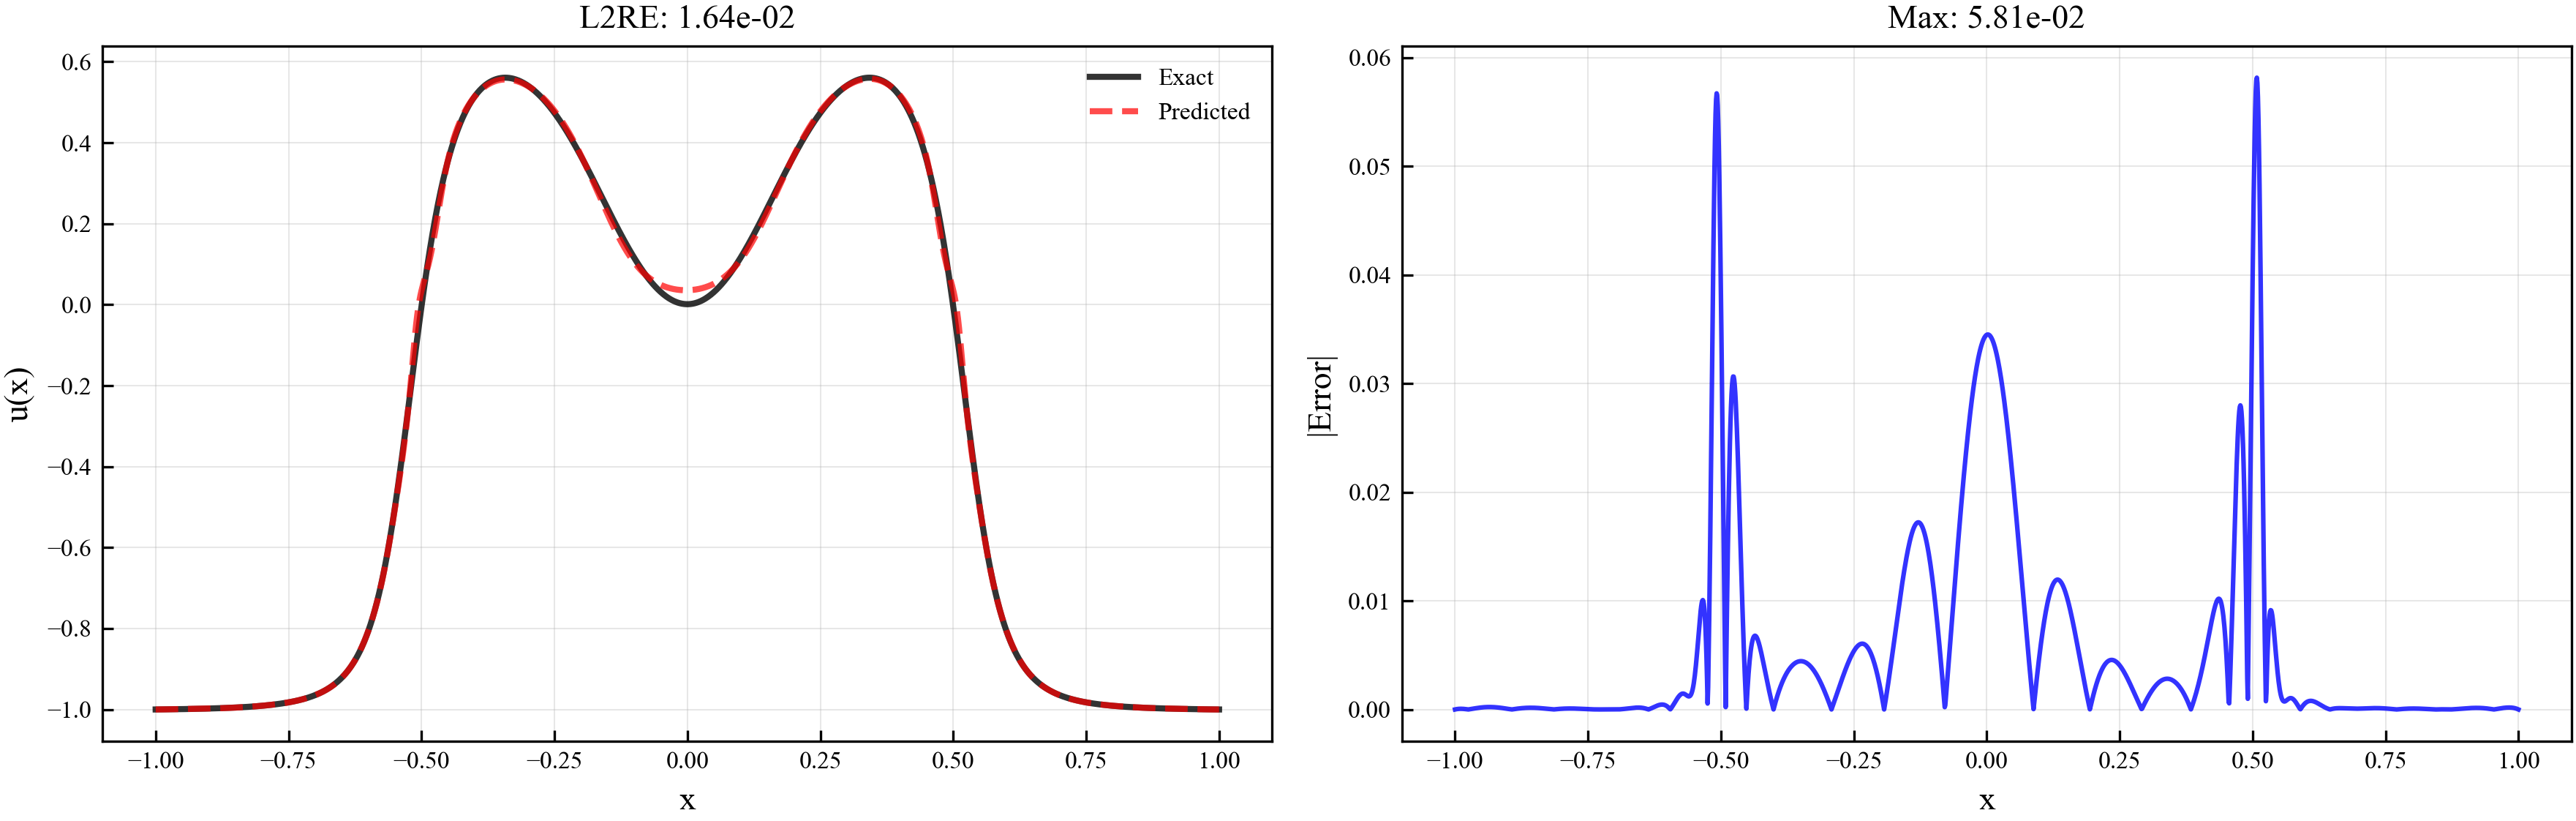

allen-cahn_L1_lambda_1e-05


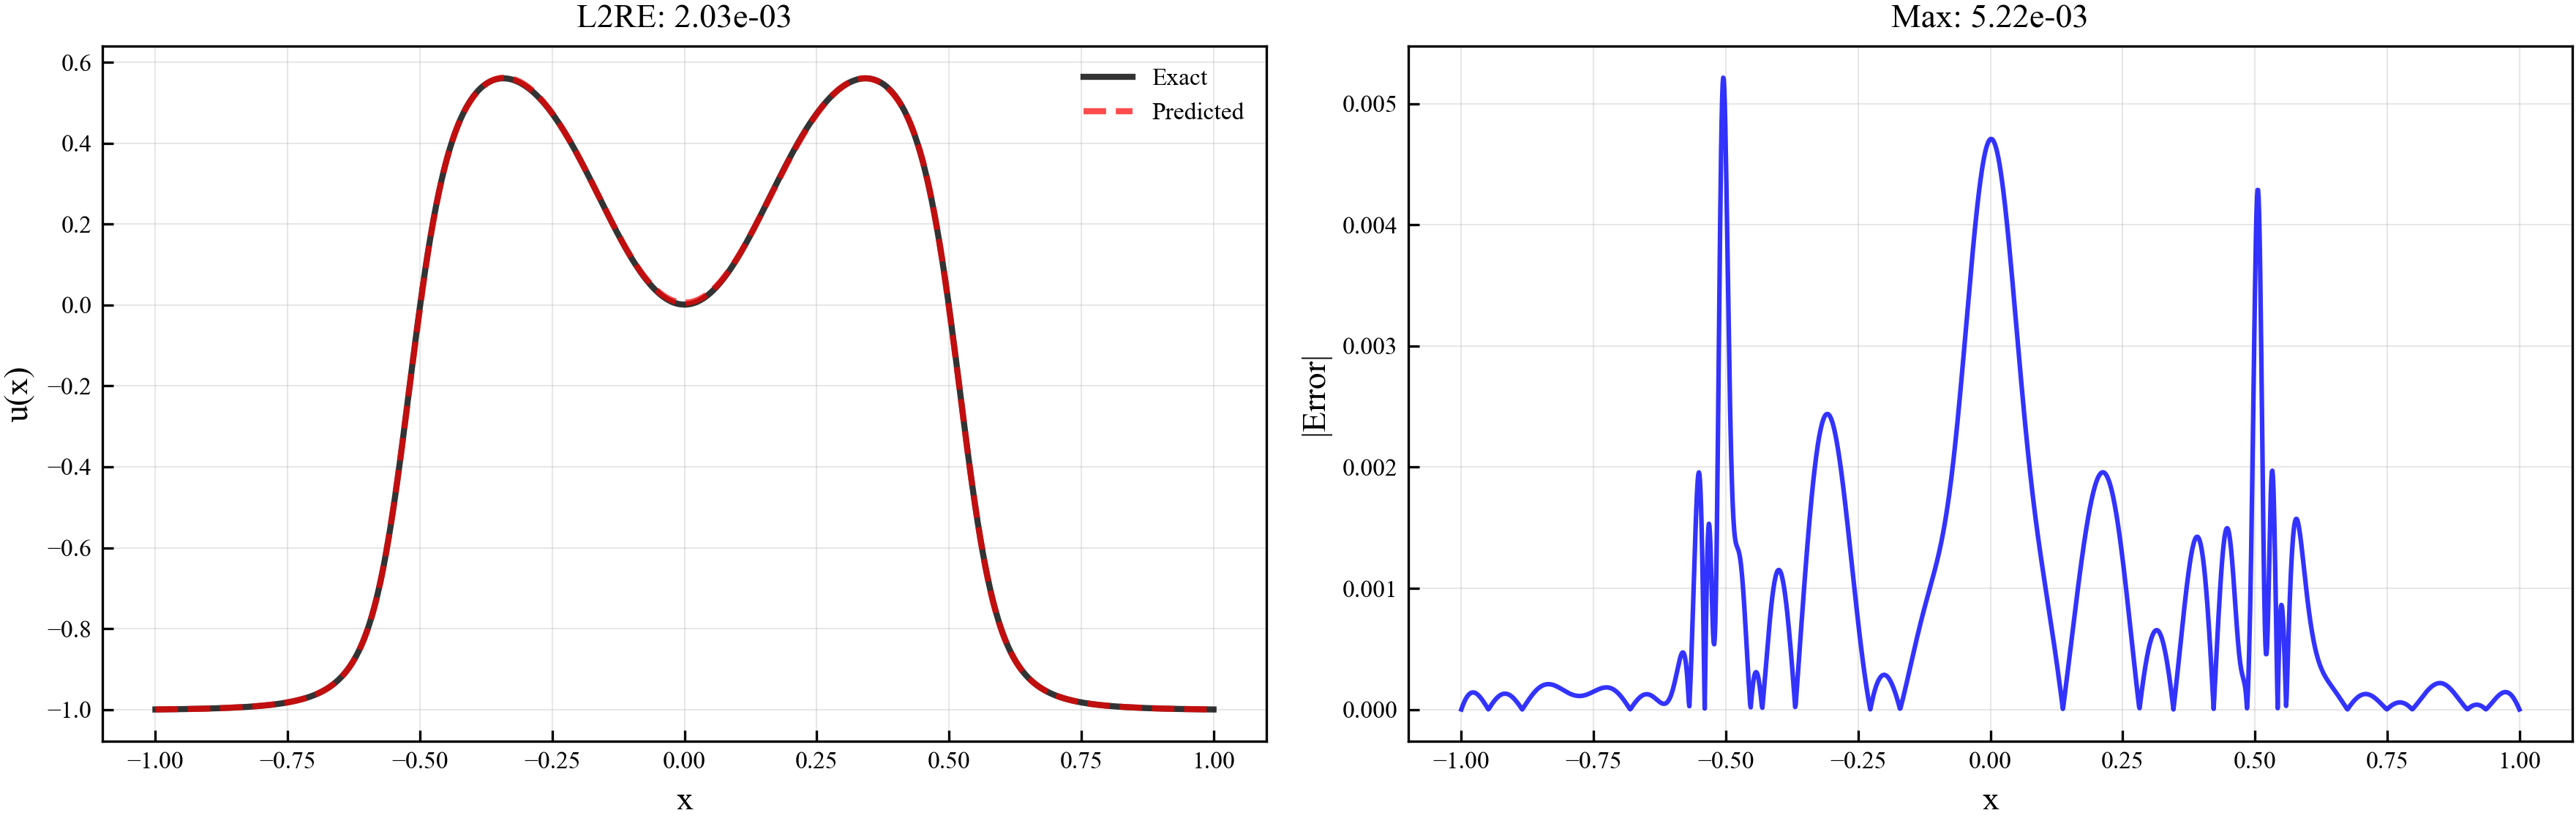

allen-cahn_UR_lambda_1e-07


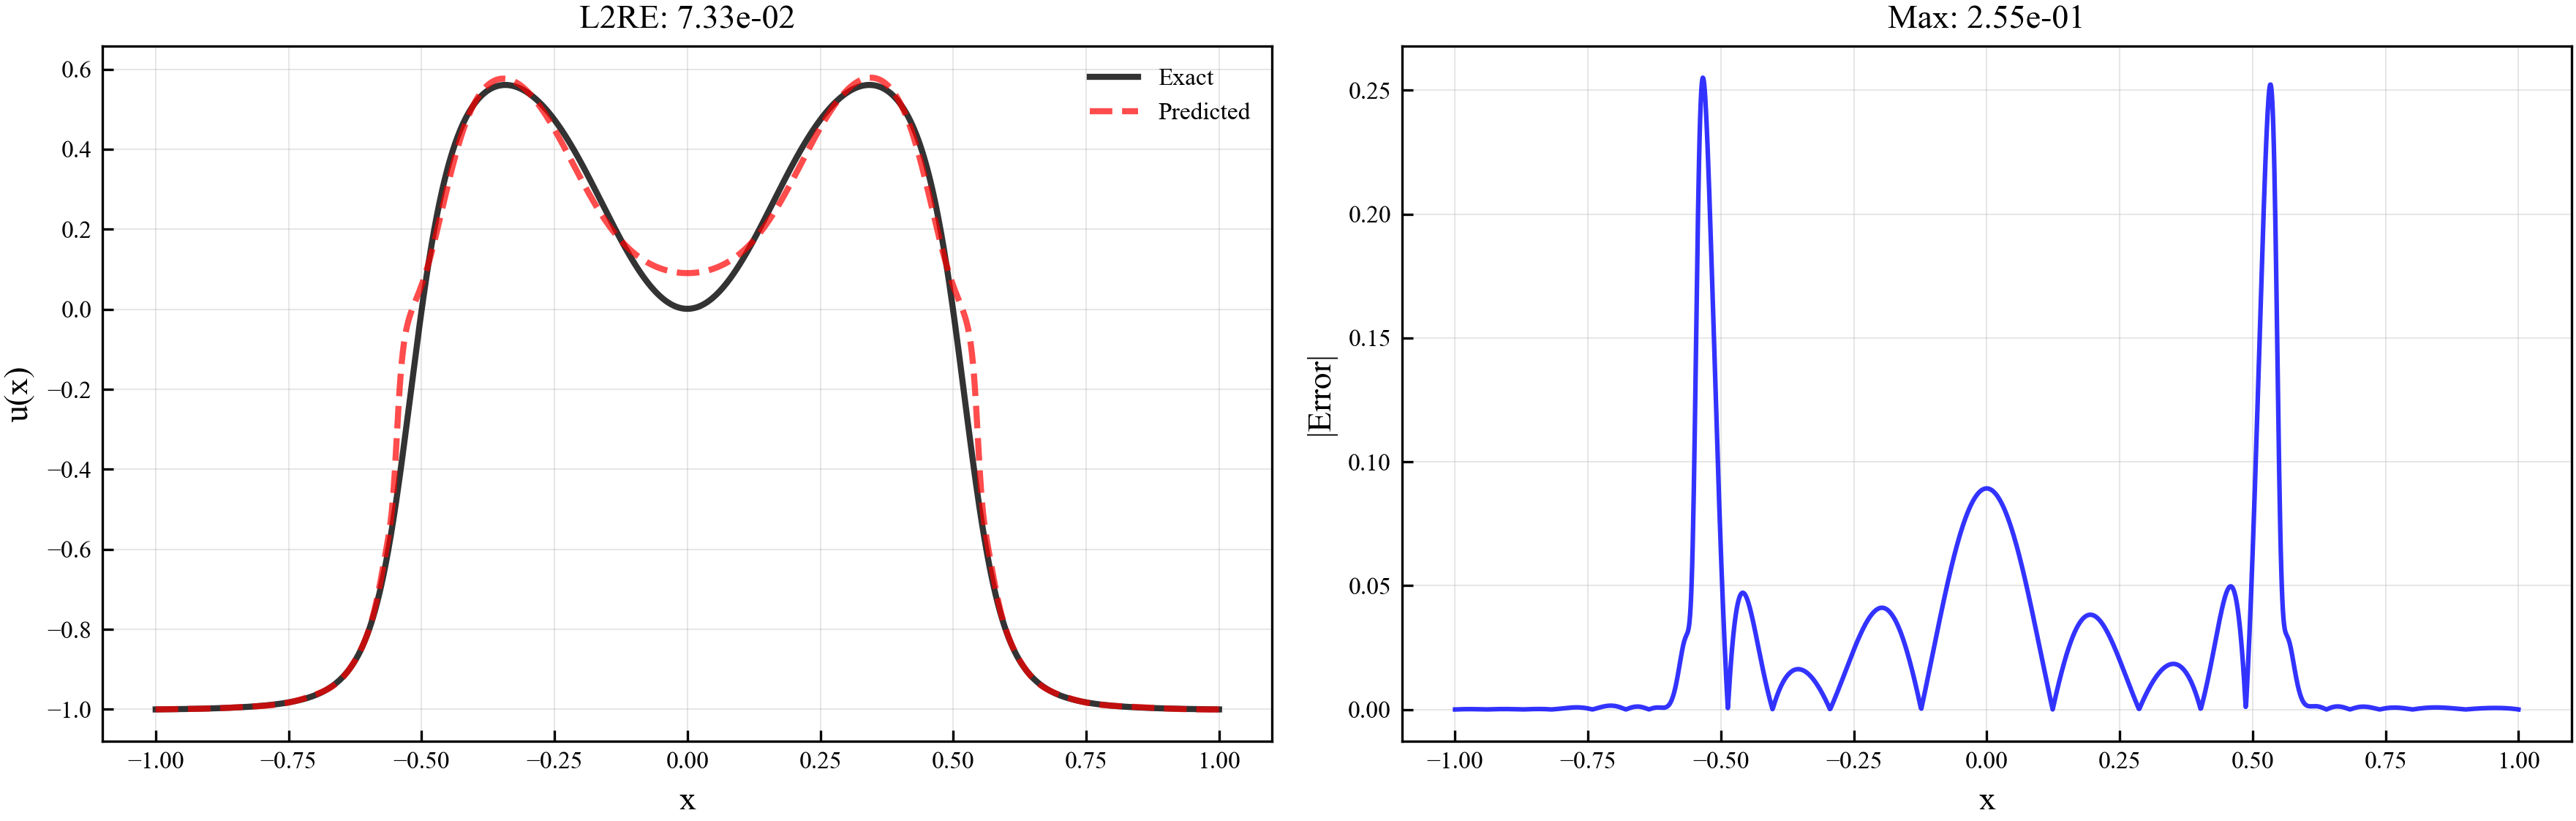

In [13]:
for dir in allen_cahn_dirs:
  solver = results_allen_cahn[0]["solver"]
  solver = load_nets(f"./final_model_states/david_finall/allen-cahn_52/{dir}/solution_epoch_5300.pt", solver, load_best_nets=True)[0]
  sol = solver.get_solution()
  u_pred = sol(x, t_1d, r)
  print(dir)
  plot_1d_solution_comparison(x, u_pred, u_ref_allen_cahn, filename=f"solution_{dir}".replace(".", "_"), save_dir="./final_plots/allen_cahn")

#### Burgers

In [14]:
burger_spec = EquationSpec(
    name="burgers",
    equation_factory=burgers_equation,
    ic_fn=burgers_ic,
    bc_left_builder=make_burgers_bc_left,
    bc_right_builder=make_burgers_bc_right,
    exact_fns_container=None,
    numerical_solution_func=solve_burgers,
    equations_number=1,
    ib_conditions_size=1,
    seed=52,
)

register_equation(burger_spec)

burgers_run = make_run_config(
    equation_name="burgers",
    models_save_dir=f"./burgers_52",
    domain=DomainConfig(
        t_min=0.0,
        t_max=1.0,
        t_num=64,
        x_min=0.0,
        x_max=1.0,
        x_num=64,
        param_min=0.01/np.pi,
        param_max=0.01/np.pi,
        param_num=1,
    ),
      network=NetworkConfig(
        body_units=(64, 64, 64, 64),
        head_units=(32, 32),
        basis_length=32,
        input_encoding="identity",
        use_bias=True,
        weights_init_method="default",
        small_normal_std=1e-2,
    ),
    optimizer=OptimizerConfig(
        mode="lbfgs",
        lbfgs_epochs=1,
        lbfgs_lr=0.5,
        lbfgs_max_iter=75,
    ),
    train=TrainConfig(
        epochs=0,
        save_period=100,
        regularization_period=1,
    ),
    eval_cfg=EvalConfig(
        dx=0.1,
        t_i=0.5,
        param_i=0.0001,
        convergence_value=1e-3,
        period=1,
    ),
    regularizations={None: [0.0]},
    )


results_burgers = run_experiment(burgers_run)

Training Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Training Progress: 100%|██████████| 1/1 [00:08<00:00,  8.83s/it]


In [15]:
local_head = 0
dt = 0.001
r_i = 0.01/np.pi
t_i = 0.5

x = torch.arange(
    0, 1 + dt, dt, requires_grad=True, device=device if "device" in globals() else None
)
t_1d = torch.full_like(x, t_i, requires_grad=True, device=x.device)
r = torch.full_like(x, r_i, requires_grad=True, device=x.device)

_, _, u_ref_burgers = solve_burgers(r_i, 1e-4, t_i, 0, 0, 1.0, dt)

In [16]:
base = "./final_model_states/david_finall/burgers_52"
burgers_dirs = [d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]

burgers_J_lambda_0.1


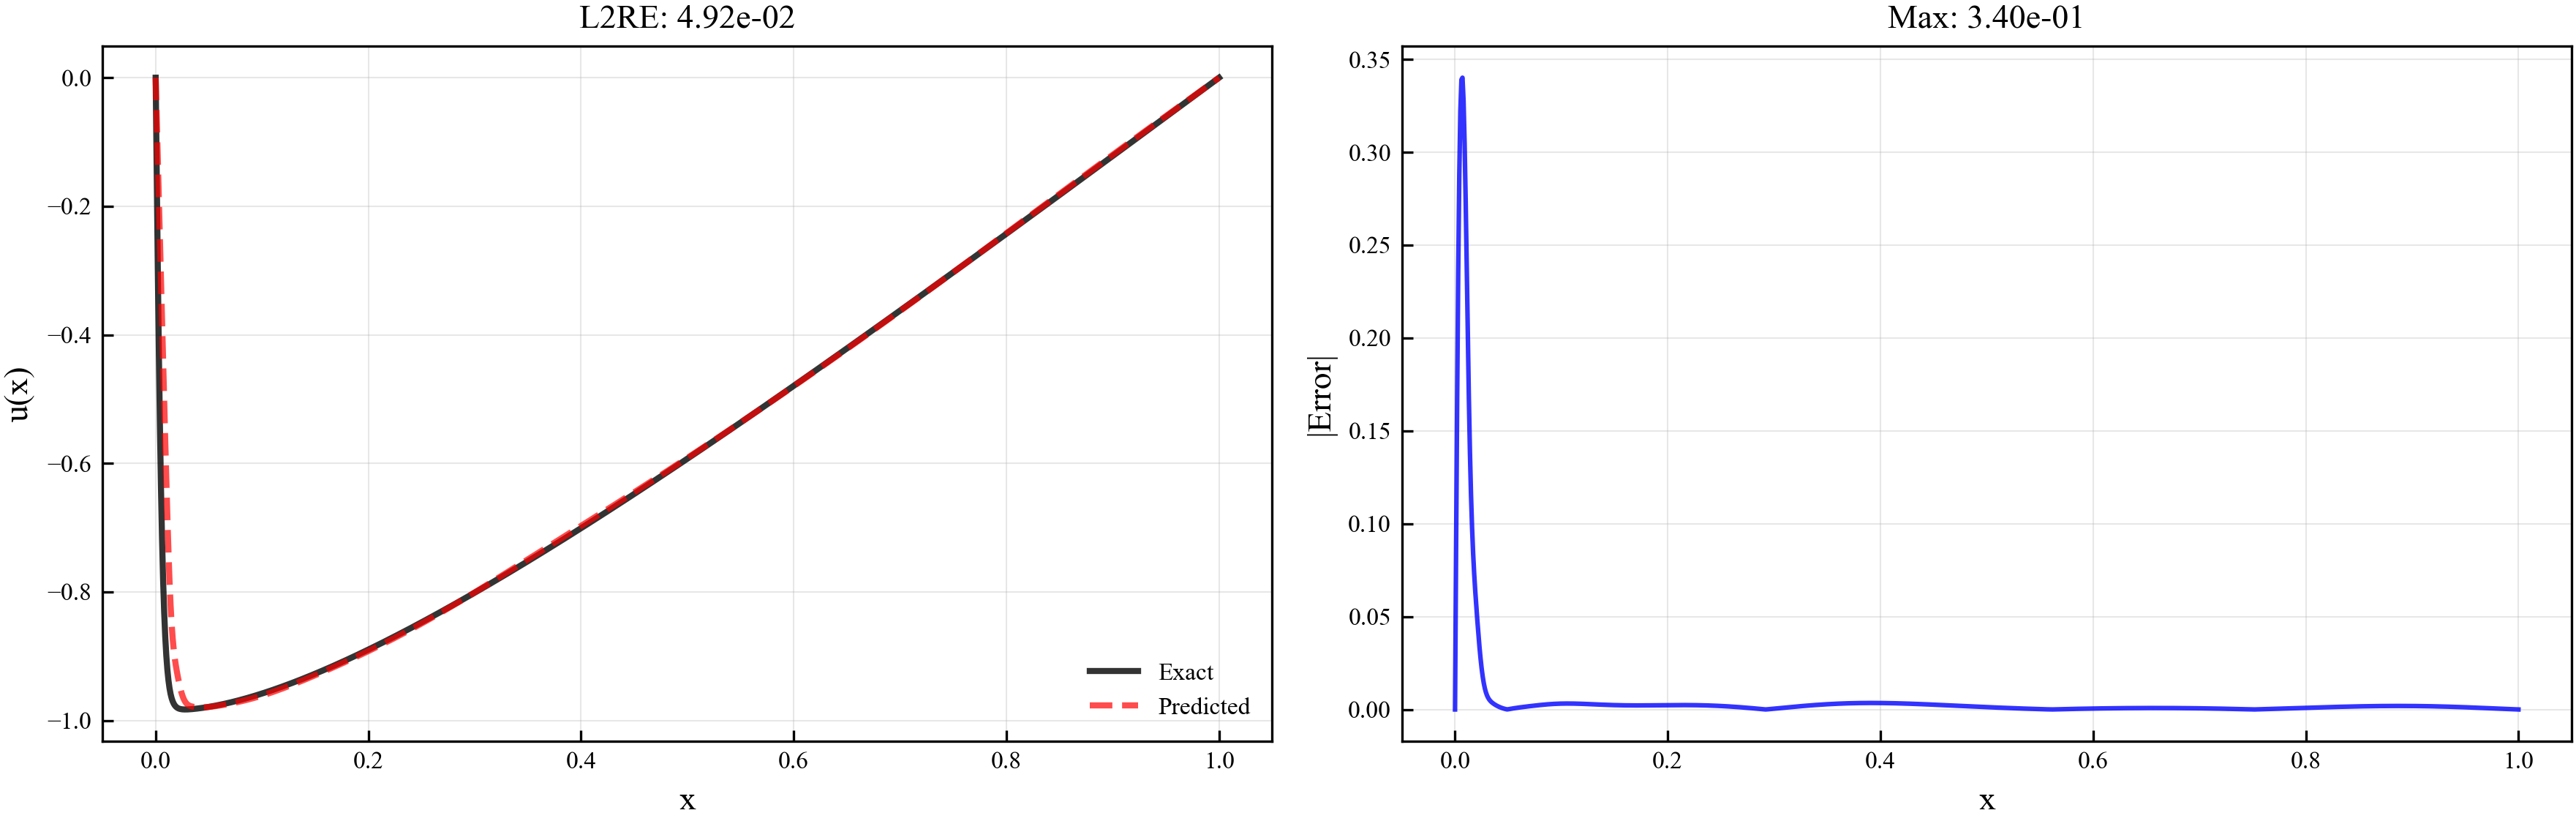

burgers_None_lambda_0.0


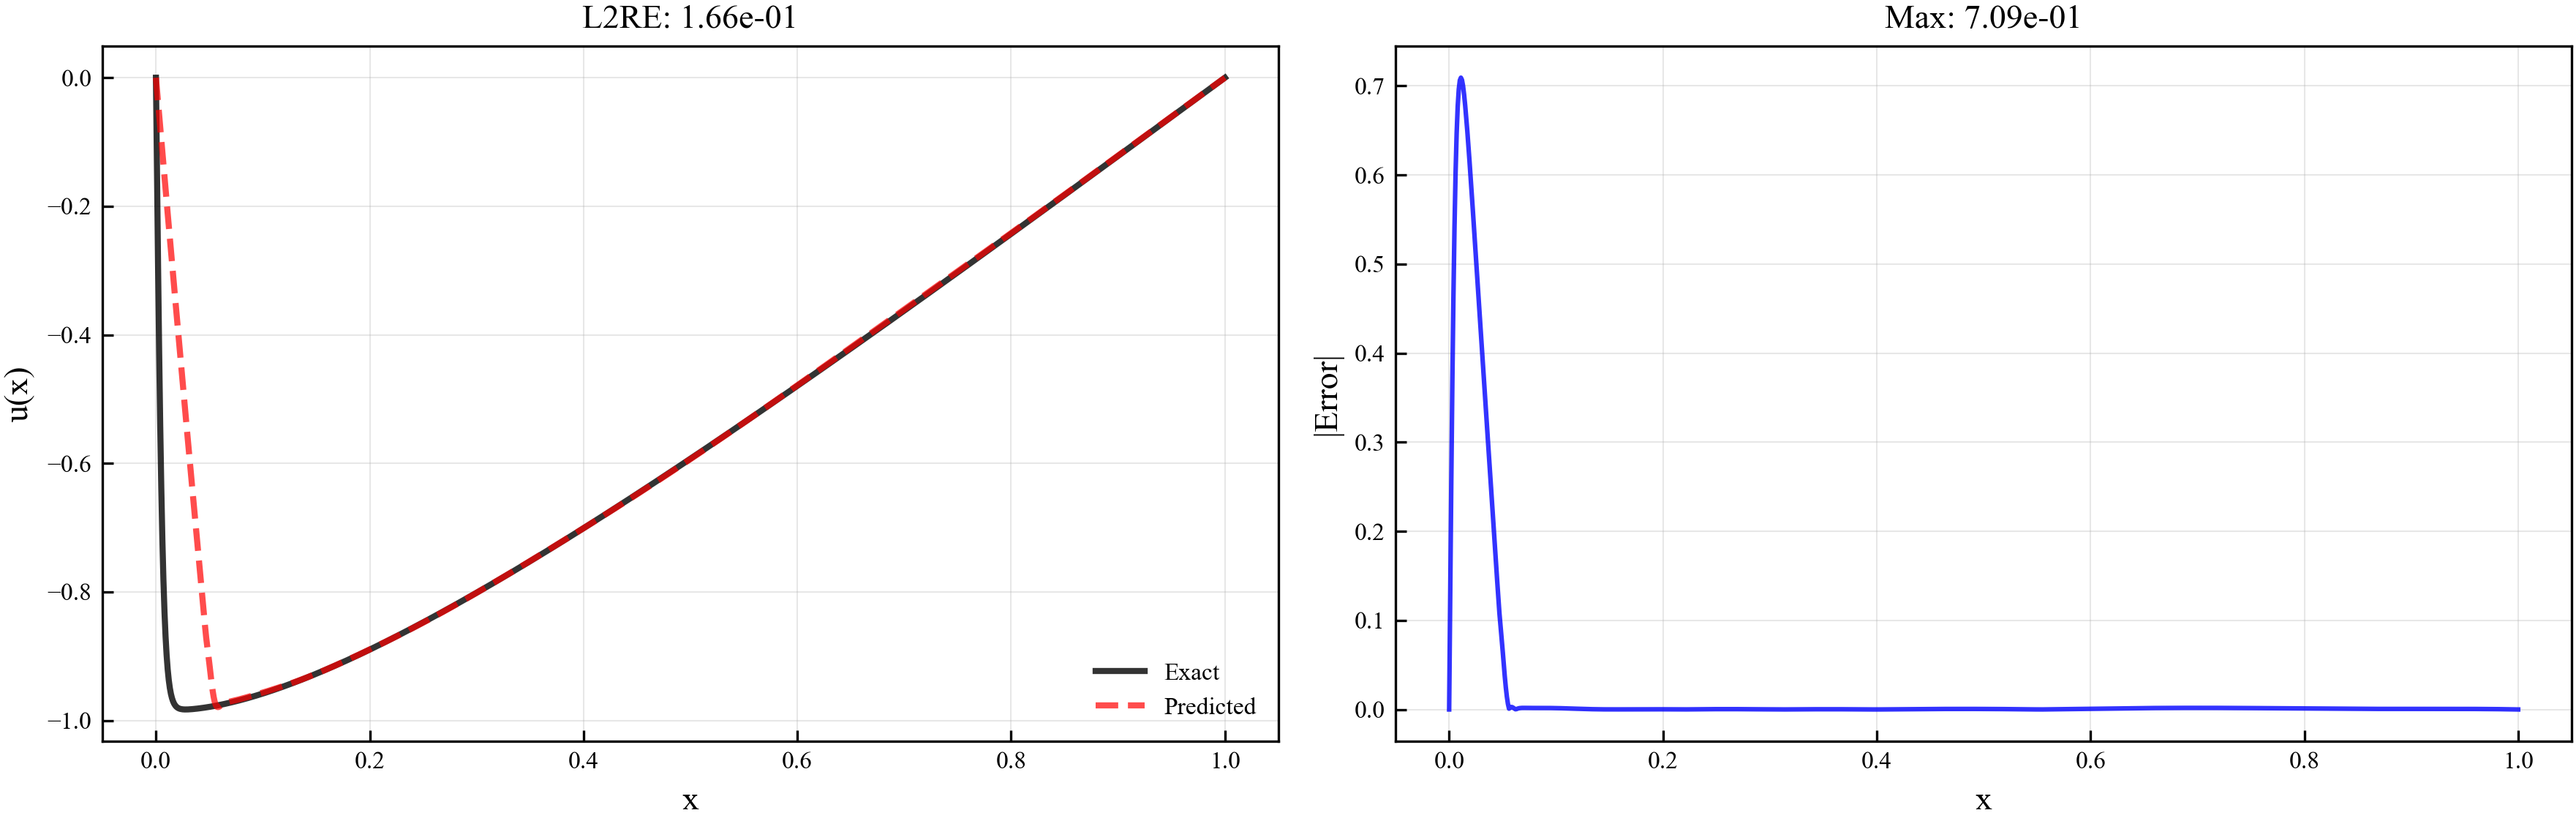

burgers_L2_lambda_100.0


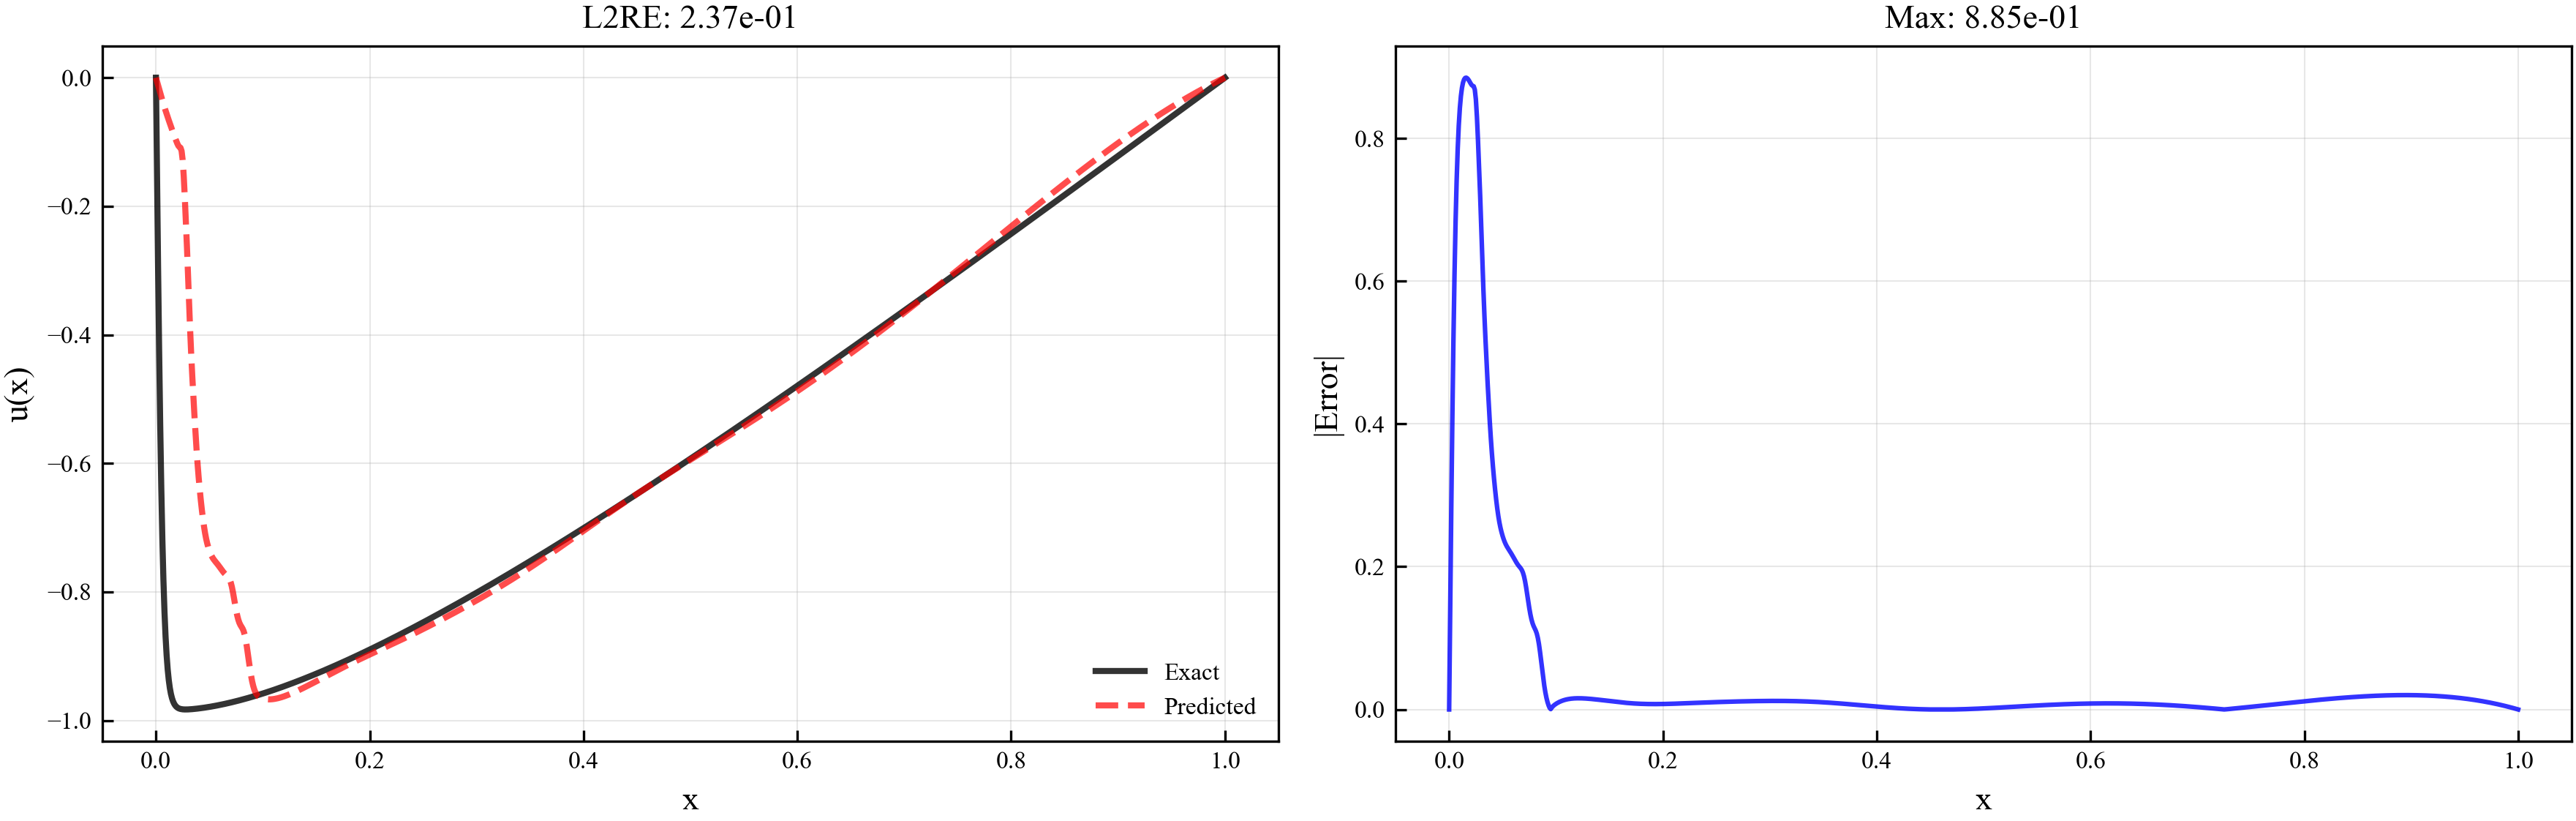

burgers_L1_lambda_0.0001


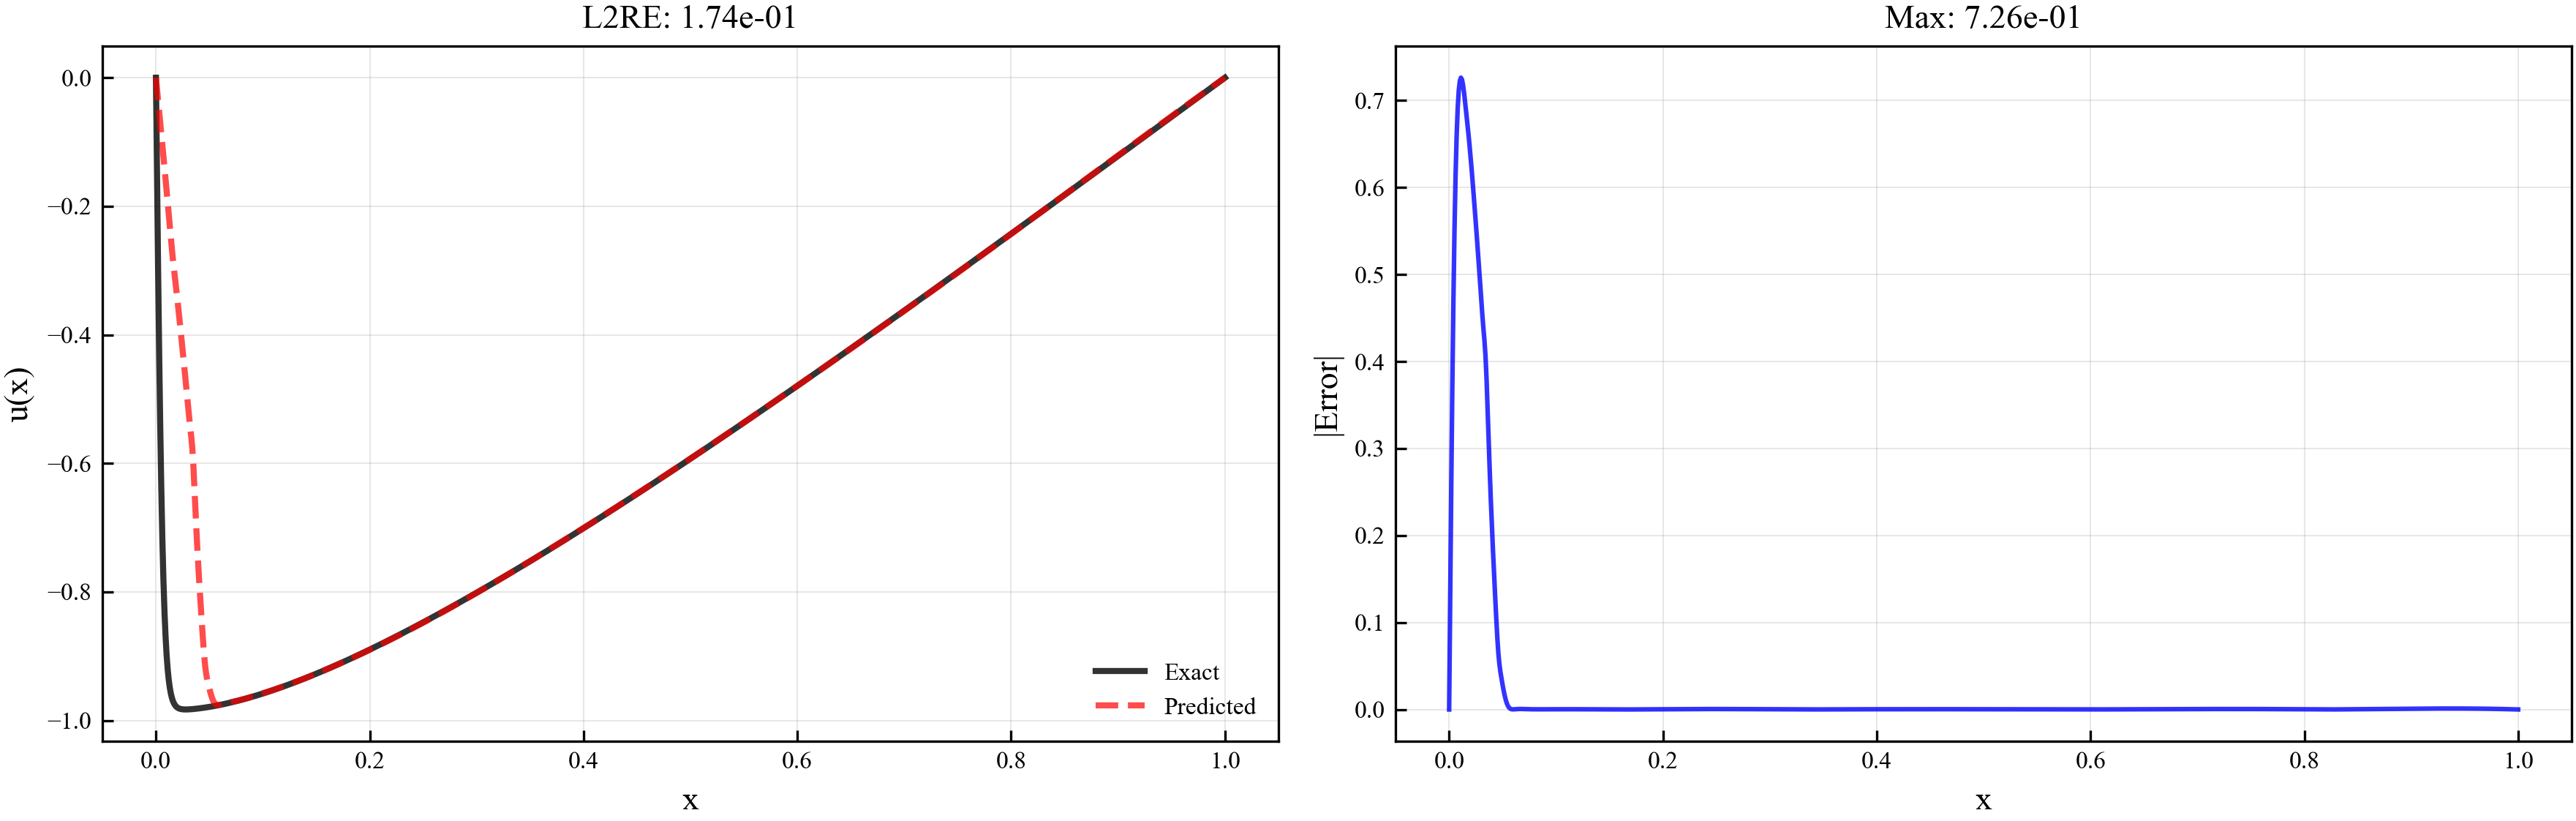

burgers_gPINN_lambda_1e-07


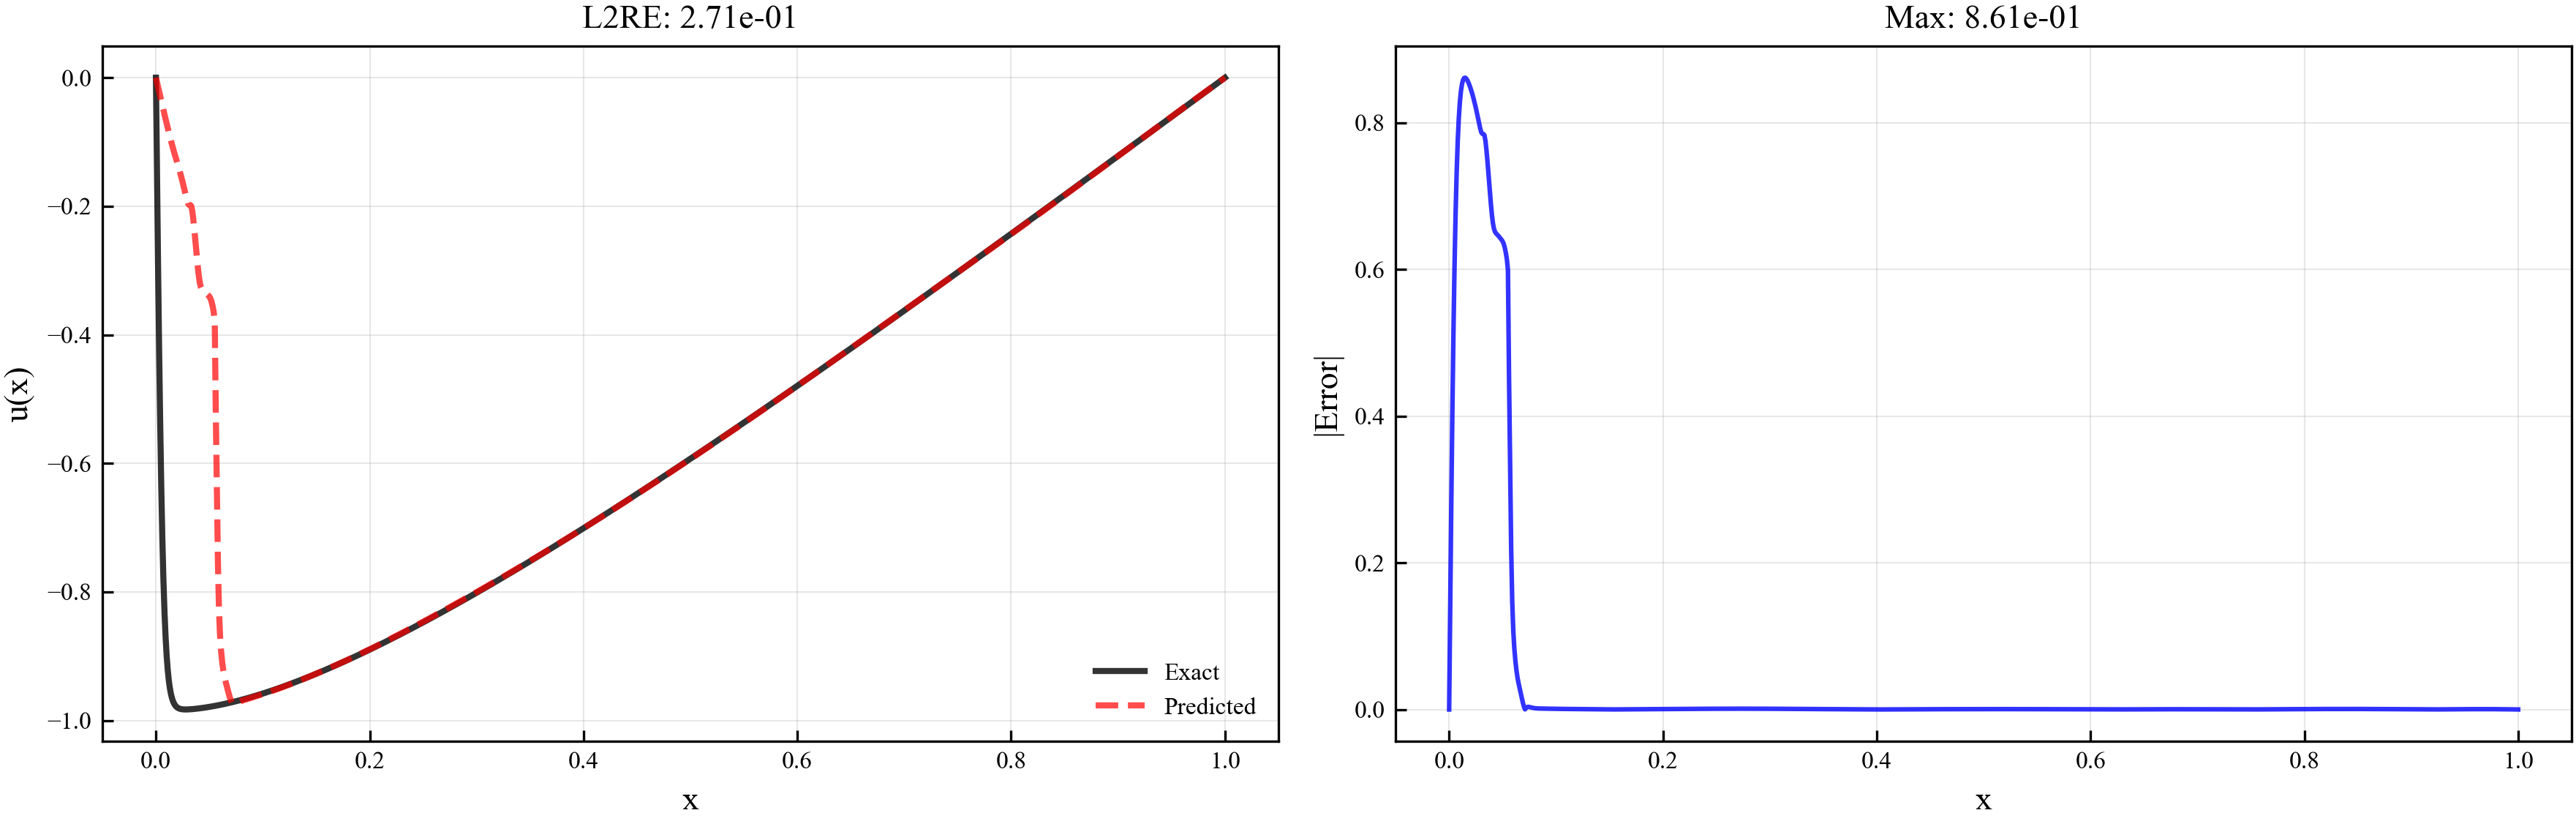

burgers_UR_lambda_1e-06


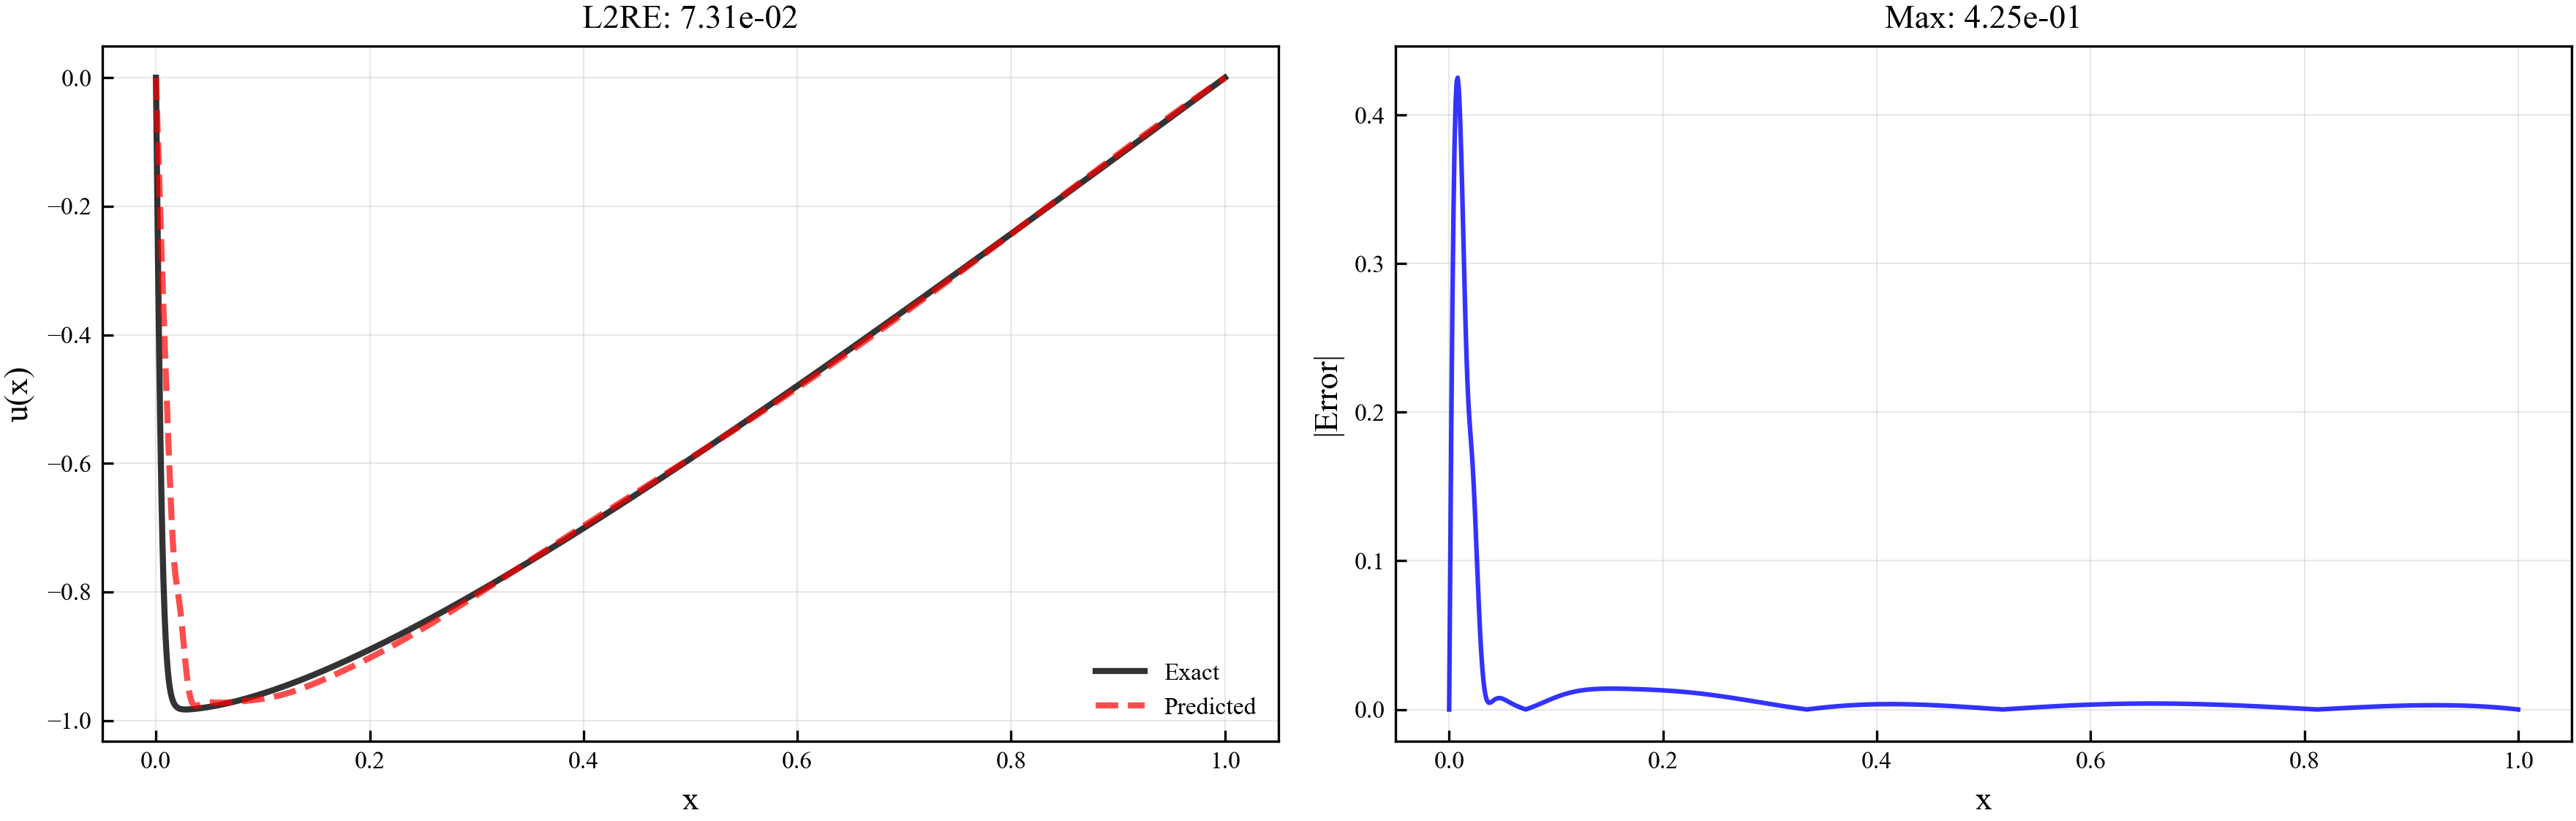

In [17]:
for dir in burgers_dirs:
  solver = results_burgers[0]["solver"]
  load_path = f"./final_model_states/david_finall/burgers_52/{dir}/solution_epoch_5300.pt"
  solver = load_nets(load_path, solver, load_best_nets=True)[0]
  sol = solver.get_solution()
  u_pred = sol(x, t_1d, r)
  print(dir)
  plot_1d_solution_comparison(x, u_pred, u_ref_burgers, filename=f"solution_{dir}".replace(".", "_"), save_dir="./final_plots/burgers")

#### Fisher

In [18]:
fisher_spec = EquationSpec(
    name="fisher",
    equation_factory=fisher_kpp_equation,
    ic_fn=fisher_ic,
    bc_left_builder=make_fisher_bc_left,
    bc_right_builder=make_fisher_bc_right,
    numerical_solution_func=solve_fisher_kpp,
    equations_number=1,
    ib_conditions_size=1,
    seed=52,
)

register_equation(fisher_spec)
fisher_run = make_run_config(
    equation_name="fisher",
    models_save_dir=f"./fisher_{52}",
    domain=DomainConfig(
        t_min=0.0,
        t_max=1.0,
        t_num=64,
        x_min=0.0,
        x_max=1.0,
        x_num=64,
        param_min=0.01,
        param_max=0.01,
        param_num=1,
    ),
    network=NetworkConfig(
        body_units=(20, 20, 20, 20),
        head_units=(16, 16),
        basis_length=8,
        use_bias=False,
        small_normal_std=1e-2,
    ),
    optimizer=OptimizerConfig(
        mode="lbfgs",
        lbfgs_epochs=1,
        lbfgs_lr=0.5,
        lbfgs_max_iter=75,
    ),
    train=TrainConfig(
        epochs=0,
        save_period=100,
        regularization_period=1,
    ),
    eval_cfg=EvalConfig(
        dx=0.1,
        t_i=0.5,
        param_i=0.0001,
        convergence_value=1e-3,
        period=1,
    ),
    regularizations={None: [0.0]},)

results_fisher = run_experiment(fisher_run)

Training Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Training Progress: 100%|██████████| 1/1 [00:04<00:00,  4.05s/it]


In [19]:
local_head = 0
dt = 0.001
r_i = 0.1
t_i = 0.5

x = torch.arange(
    0, 1 + dt, dt, requires_grad=True, device=device if "device" in globals() else None
)
t_1d = torch.full_like(x, t_i, requires_grad=True, device=x.device)
r = torch.full_like(x, r_i, requires_grad=True, device=x.device)

_, _, u_ref_fisher = solve_fisher_kpp(r_i, 1e-4, t_i, 0, 0, 1.0, dt)

In [20]:
base = "./final_model_states/david_finall/fisher_52"
fisher_dirs = [d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]

fisher_gPINN_lambda_1e-07


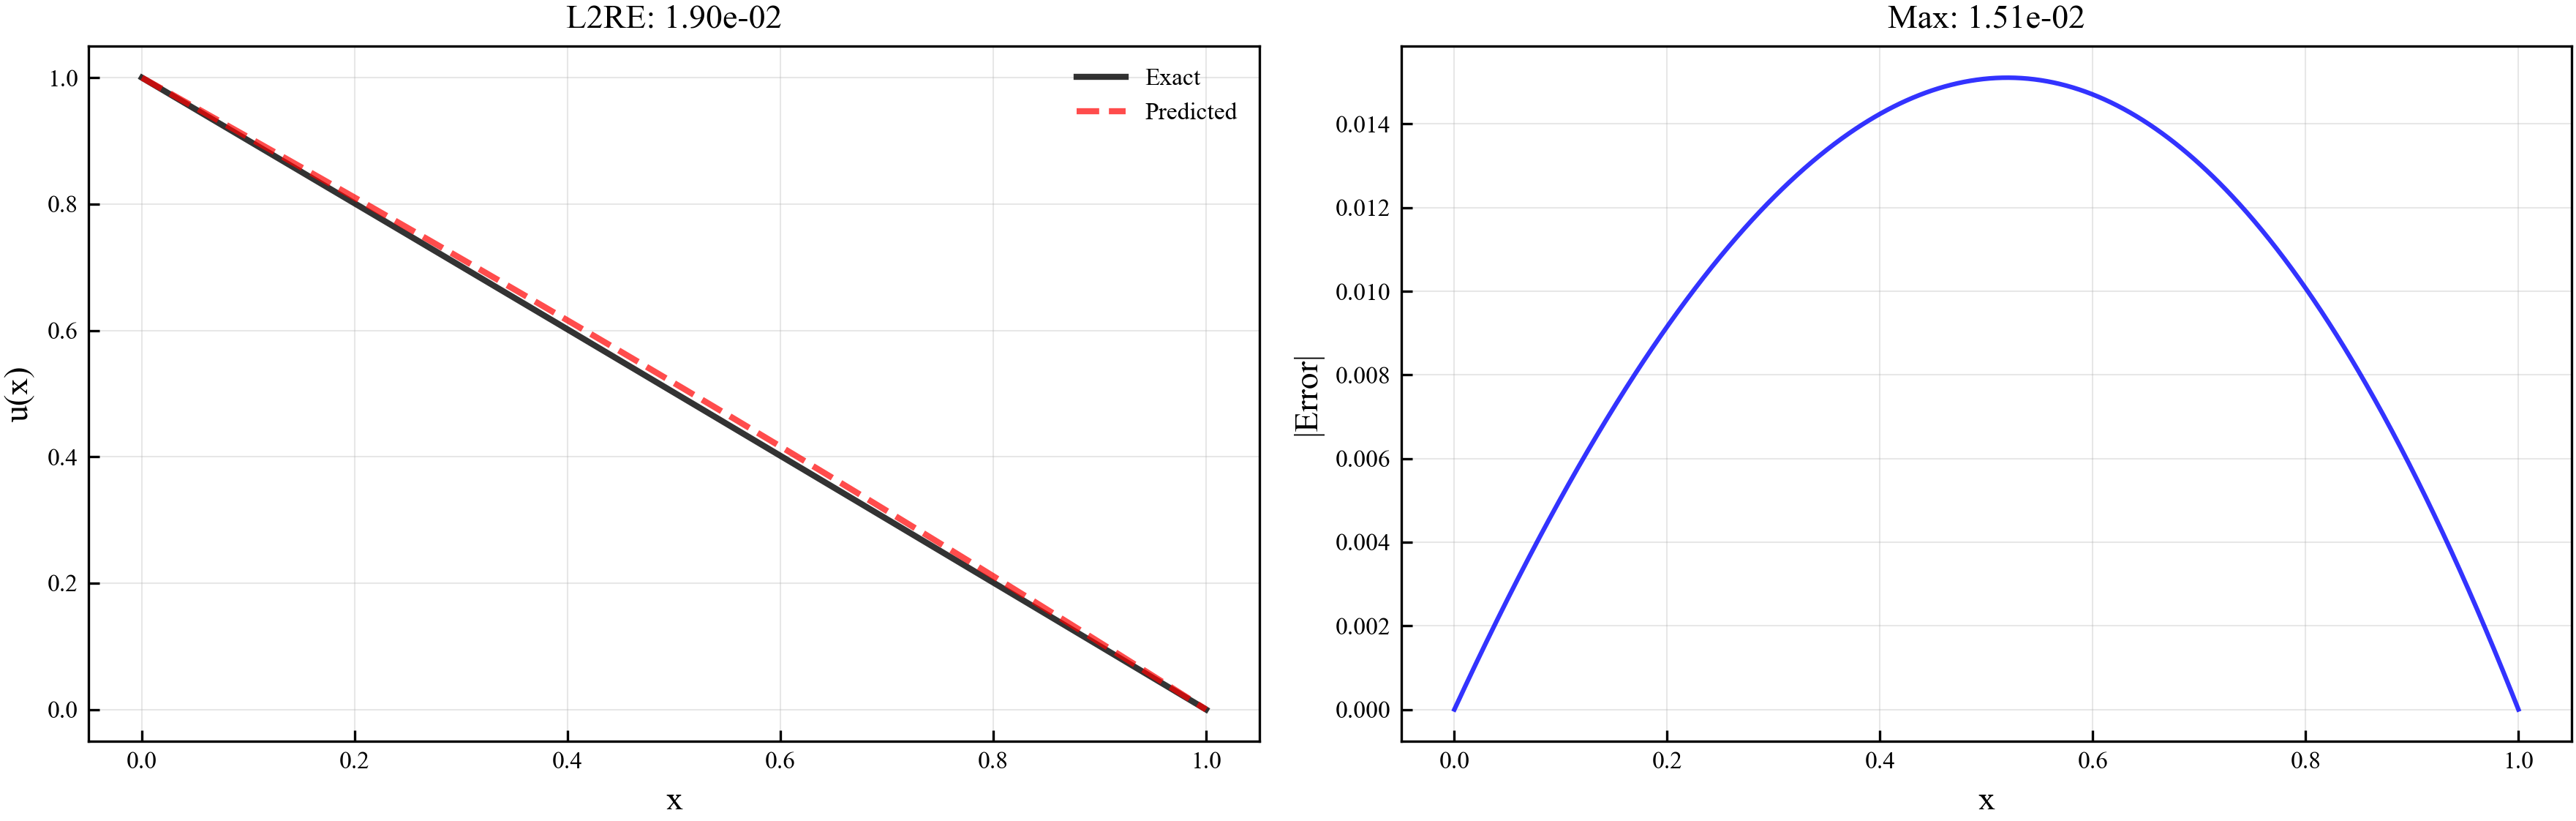

fisher_UR_lambda_1e-06


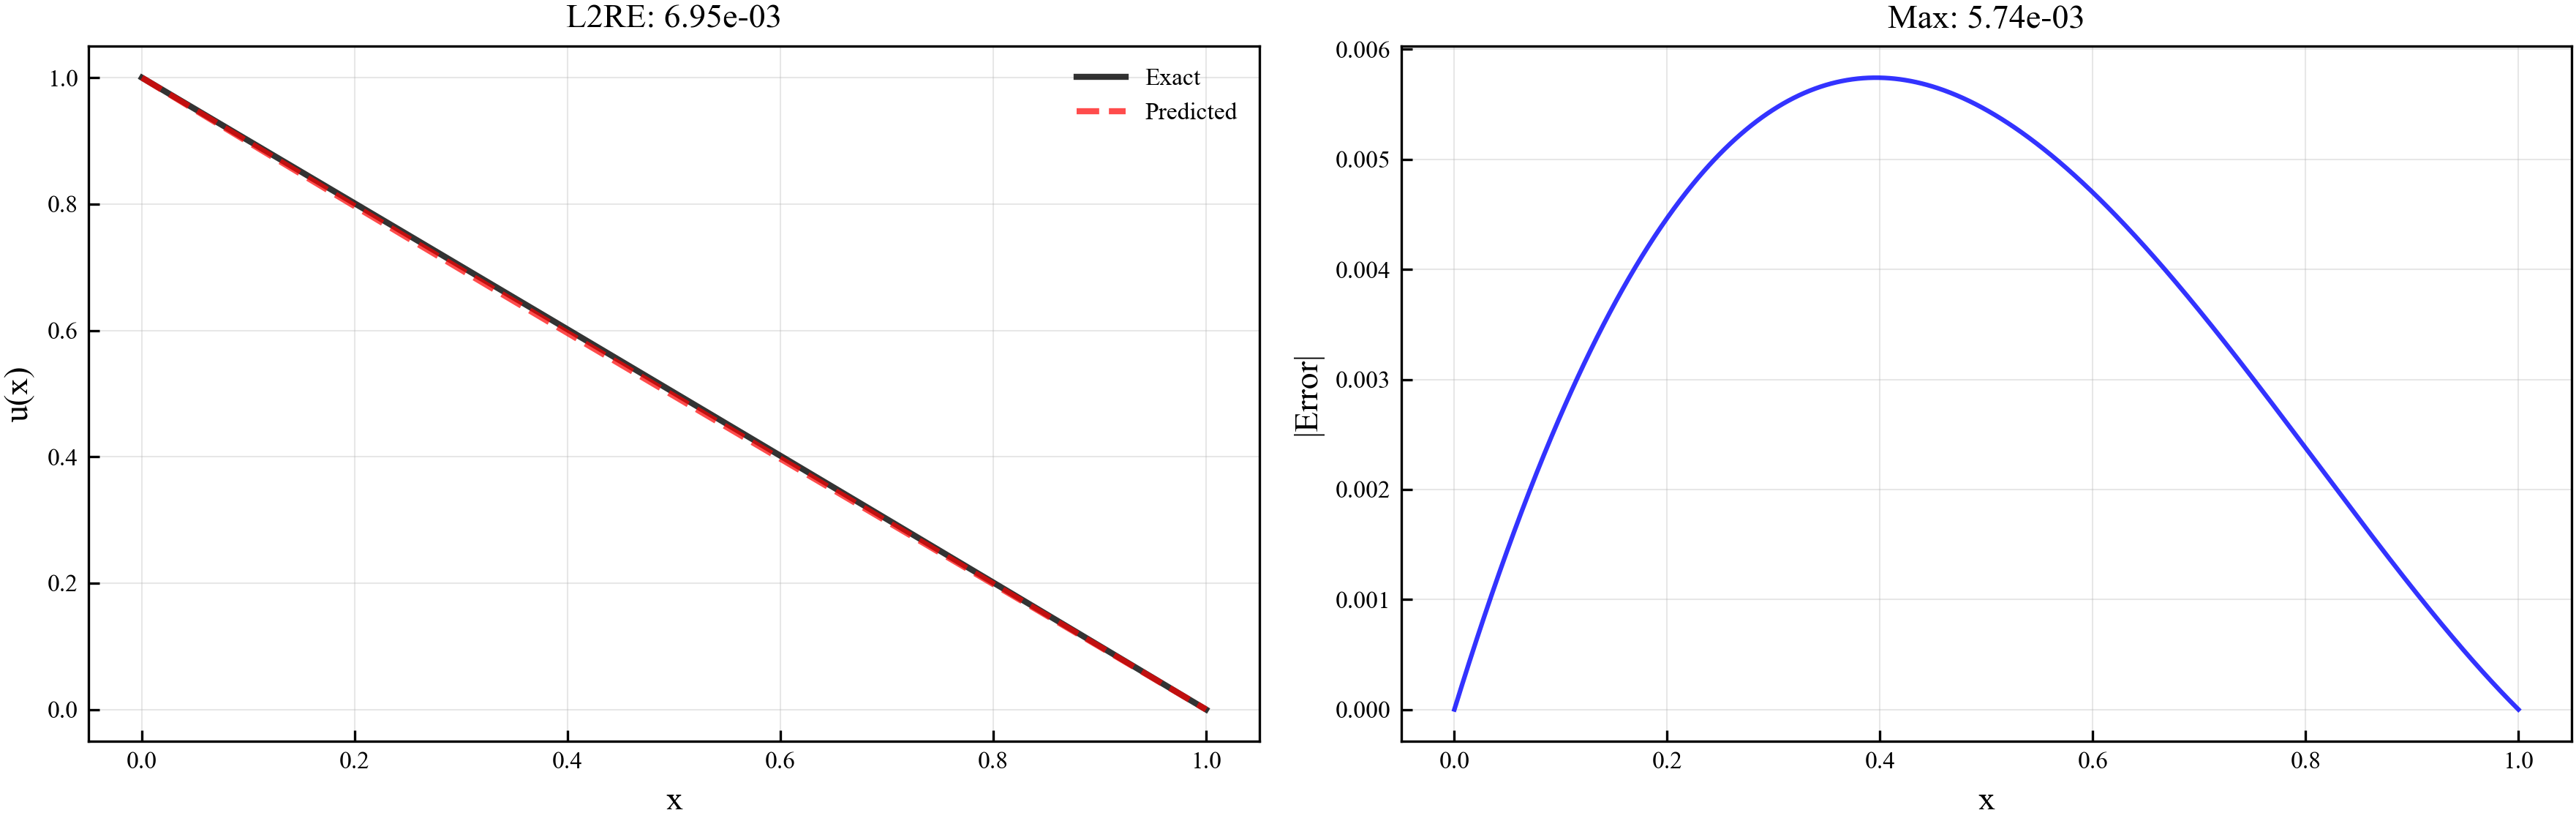

fisher_L2_lambda_1e-06


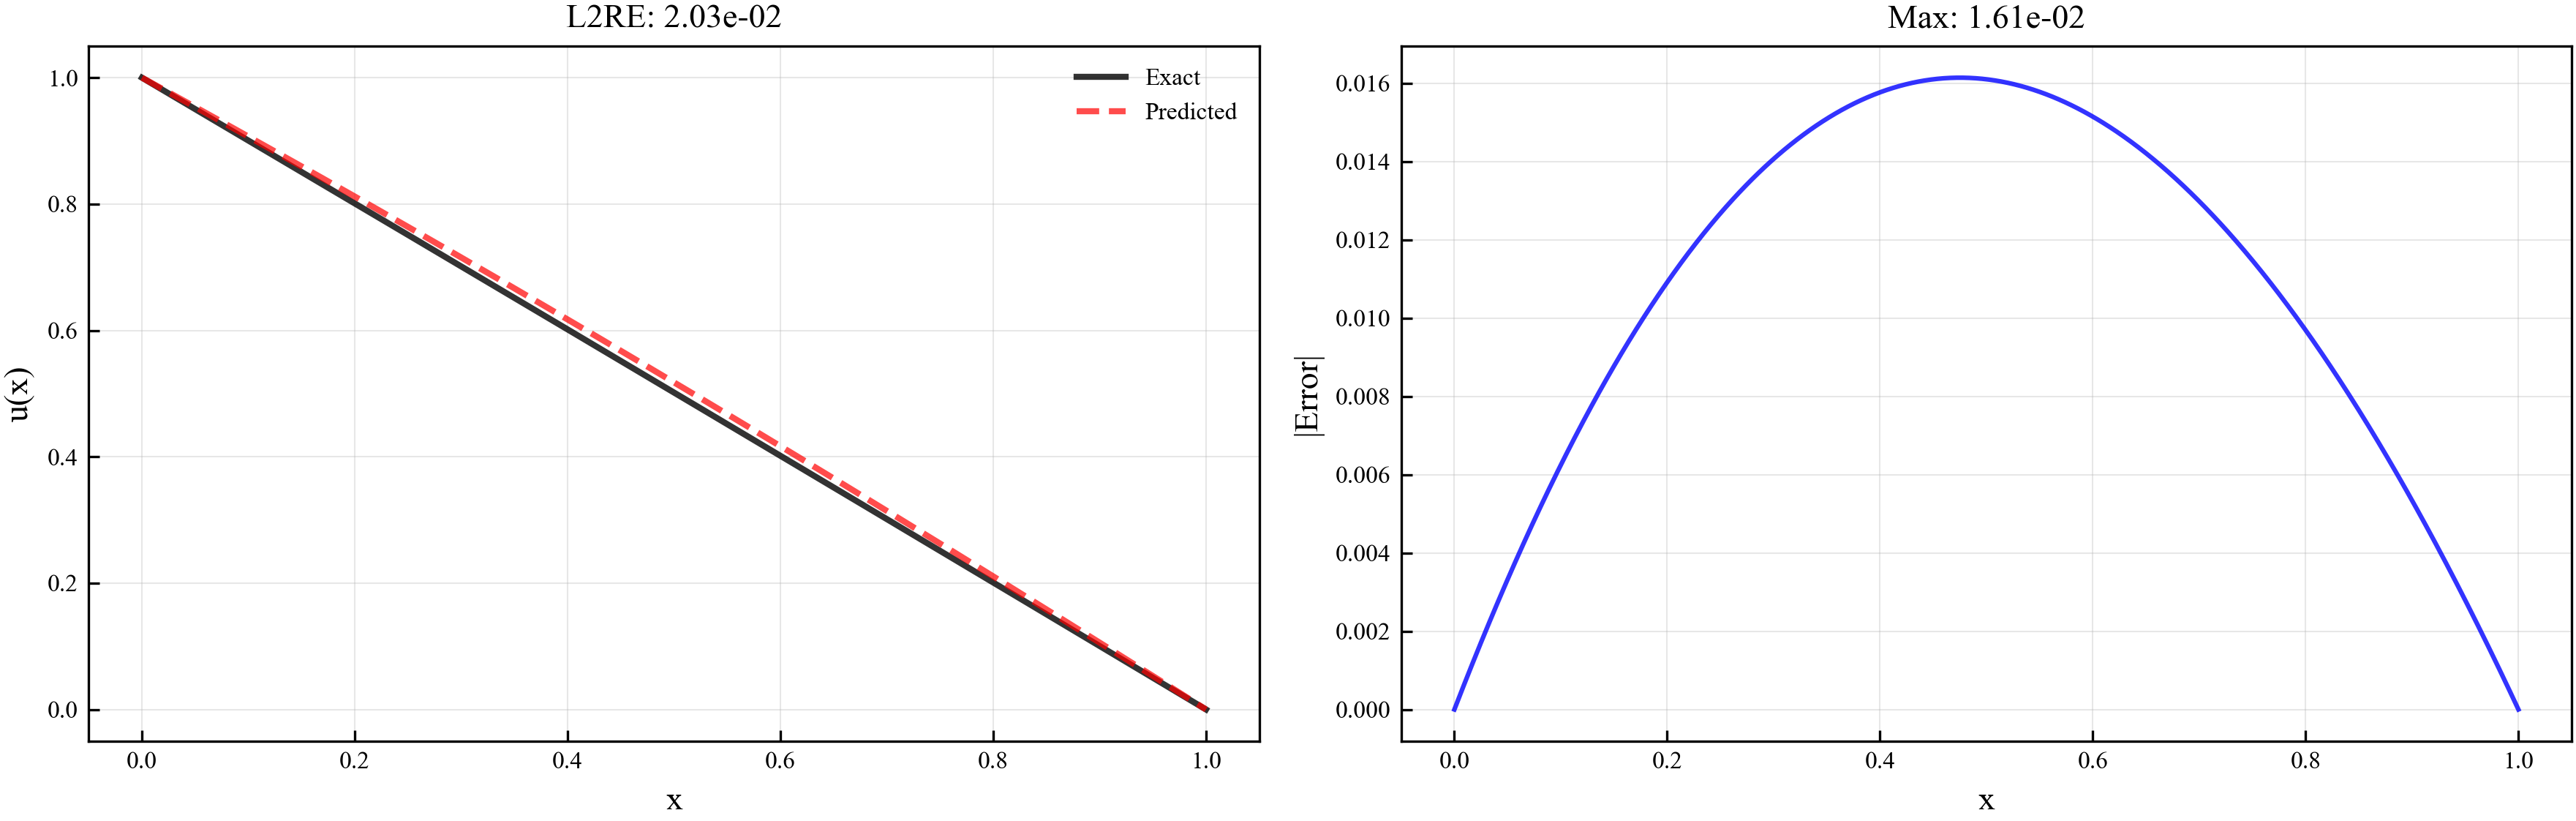

fisher_L1_lambda_1e-06


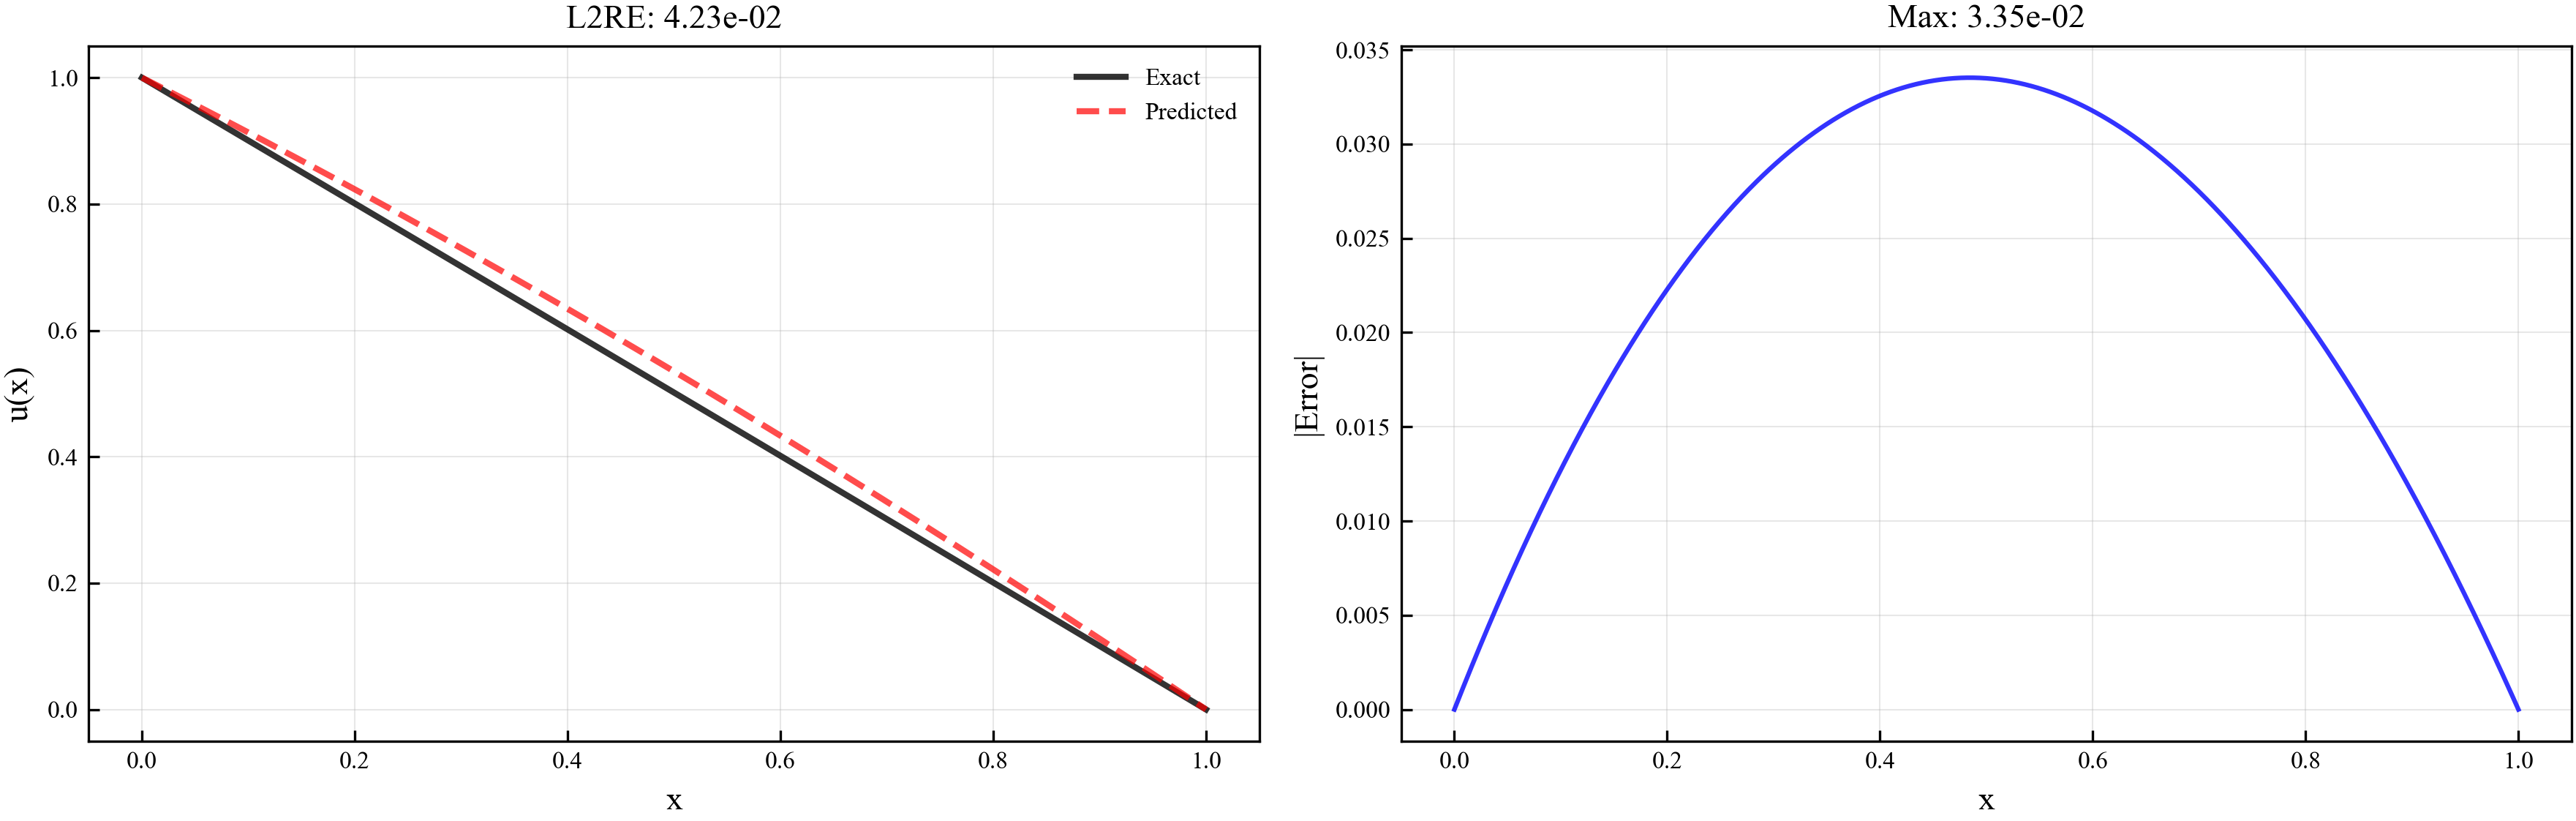

fisher_J_lambda_0.0001


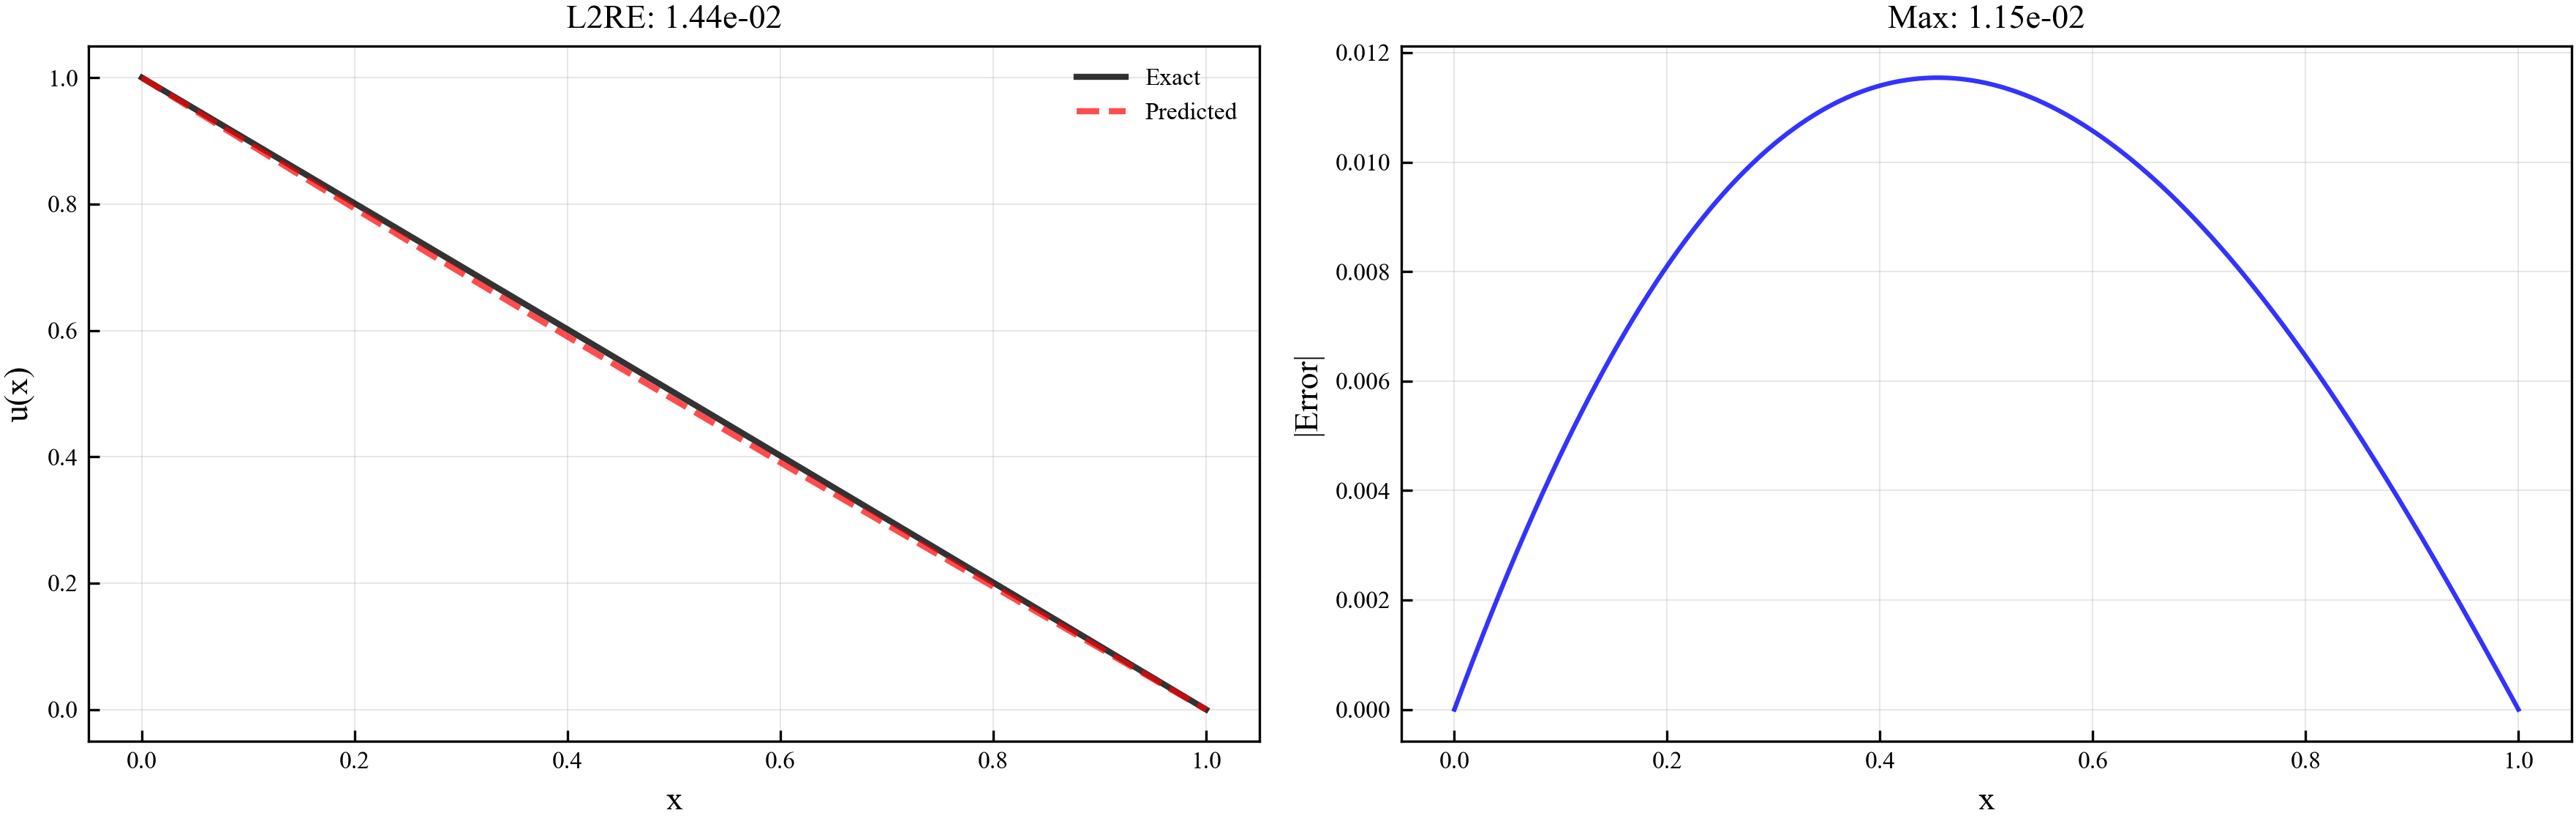

fisher_None_lambda_0.0


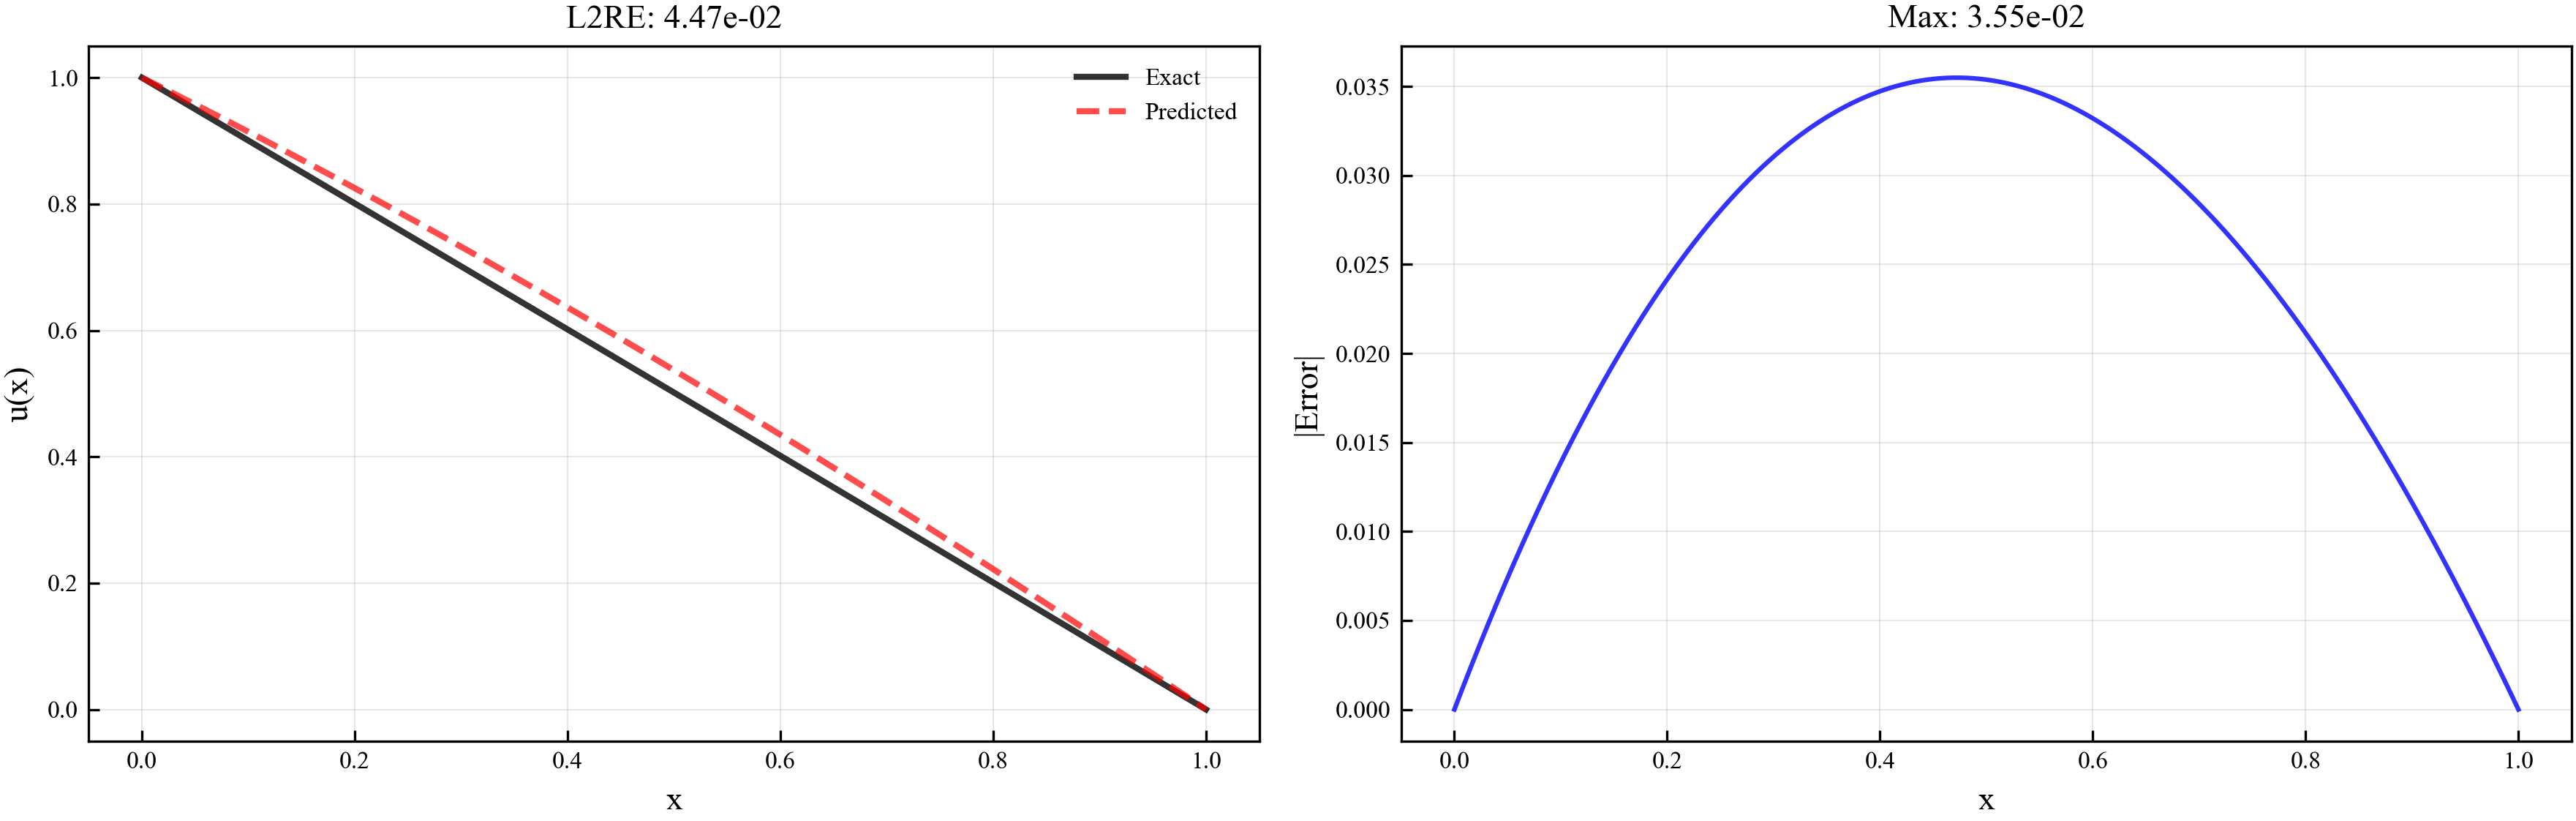

In [21]:
for dir in fisher_dirs:
  solver = results_fisher[0]["solver"]
  load_path = f"./final_model_states/david_finall/fisher_52/{dir}/solution_epoch_5300.pt"
  solver = load_nets(load_path, solver, load_best_nets=True)[0]
  sol = solver.get_solution()
  u_pred = sol(x, t_1d, r)
  print(dir)
  plot_1d_solution_comparison(x, u_pred, u_ref_fisher, filename=f"solution_{dir}".replace(".", "_"), save_dir="./final_plots/fisher")

### Solution exctraction for heatmap creation

In [22]:
EQUATION_CONFIGS = {
    "allen-cahn_52": {
        "solver": "allen_cahn",
        "parameter_name": "epsilon",
        "parameter_value": 1e-4,
        "x_left": -1.0,
        "x_right": 1.0,
        "x_num": 300,
        "t_start": 0.0,
        "t_end": 1.0,
        "t_num": 300,
    },
    "burgers_52": {
        "solver": "burgers",
        "parameter_name": "nu",
        "parameter_value": 0.01 / np.pi,
        "x_left": 0.0,
        "x_right": 1.0,
        "x_num": 300,
        "t_start": 0.0,
        "t_end": 1.0,
        "t_num": 300,
    },
    "fisher_52": {
        "solver": "fisher",
        "parameter_name": "r",
        "parameter_value": 0.01,
        "x_left": 0.0,
        "x_right": 1.0,
        "x_num": 300,
        "t_start": 0.0,
        "t_end": 1.0,
        "t_num": 300,
    },
}


def build_heatmap_inputs(config, device=None):
    x = torch.linspace(
        config["x_left"],
        config["x_right"],
        config["x_num"],
        device=device,
        requires_grad=True,
    )

    t = torch.linspace(
        config["t_start"],
        config["t_end"],
        config["t_num"],
        device=device,
        requires_grad=True,
    )

    X, T = torch.meshgrid(x, t, indexing="ij")

    P = torch.full_like(
        X,
        config["parameter_value"],
        requires_grad=True,
    )

    return x, t, X, T, P


def build_heatmap_from_solution(config, sol, device=None):
    x, t, X, T, P = build_heatmap_inputs(config, device=device)

    u_pred = sol(X, T, P)

    expected_shape = (config["x_num"], config["t_num"])
    assert u_pred.shape == expected_shape, f"Expected {expected_shape}, got {u_pred.shape}"

    return {
        "x": x,
        "t": t,
        "X": X,
        "T": T,
        "P": P,
        "u_pred": u_pred,
        "parameter_name": config["parameter_name"],
        "parameter_value": config["parameter_value"],
    }


device = device if "device" in globals() else None

heatmaps = {}

models_solvers = [
    ("fisher_52", results_fisher[0]["solver"], fisher_dirs),
    ("burgers_52", results_burgers[0]["solver"], burgers_dirs),
    ("allen-cahn_52", results_allen_cahn[0]["solver"], allen_cahn_dirs),
]

for model_path, model_solver, model_dirs in models_solvers:
  config = EQUATION_CONFIGS[model_path]

  local_heatmap = {}

  for dir in model_dirs:
      load_path = f"./final_model_states/david_finall/{model_path}/{dir}/solution_epoch_5300.pt"

      solver = load_nets(
          load_path,
          model_solver,
          load_best_nets=True,
      )[0]

      sol = solver.get_solution()

      local_heatmap[dir] = build_heatmap_from_solution(
          config=config,
          sol=sol,
          device=device,
      )
  heatmaps[model_path] = local_heatmap


In [23]:
heatmaps["fisher_52"]["fisher_gPINN_lambda_1e-07"]["u_pred"].shape

torch.Size([300, 300])

In [24]:
def tensor_to_list(t):
    return t.detach().cpu().numpy().tolist()


def heatmaps_to_json_serializable(heatmaps):
    result = {}

    for model_name, model_data in heatmaps.items():
        result[model_name] = {}

        for dir_name, data in model_data.items():
            result[model_name][dir_name] = {
                "x": tensor_to_list(data["x"]),
                "t": tensor_to_list(data["t"]),
                "u_pred": tensor_to_list(data["u_pred"]),
                "parameter_name": data["parameter_name"],
                "parameter_value": data["parameter_value"],
            }

    return result


json_data = heatmaps_to_json_serializable(heatmaps)

with open("heatmaps.json", "w") as f:
    json.dump(json_data, f)

### Compare plot: Numerical vs Best-Reg vs Vanilla

#### Allen-Cahn

In [25]:
local_head = 0
dt = 0.001
r_i = 0.0001
t_i = 0.5

x = torch.arange(
    -1.0, 1 + dt, dt, requires_grad=True, device=device if "device" in globals() else None
)
t_1d = torch.full_like(x, t_i, requires_grad=True, device=x.device)
r = torch.full_like(x, r_i, requires_grad=True, device=x.device)

_, _, u_ref_allen_cahn = solve_allen_cahn(r_i, 1e-4, t_i, 0, -1.0, 1.0, dt)

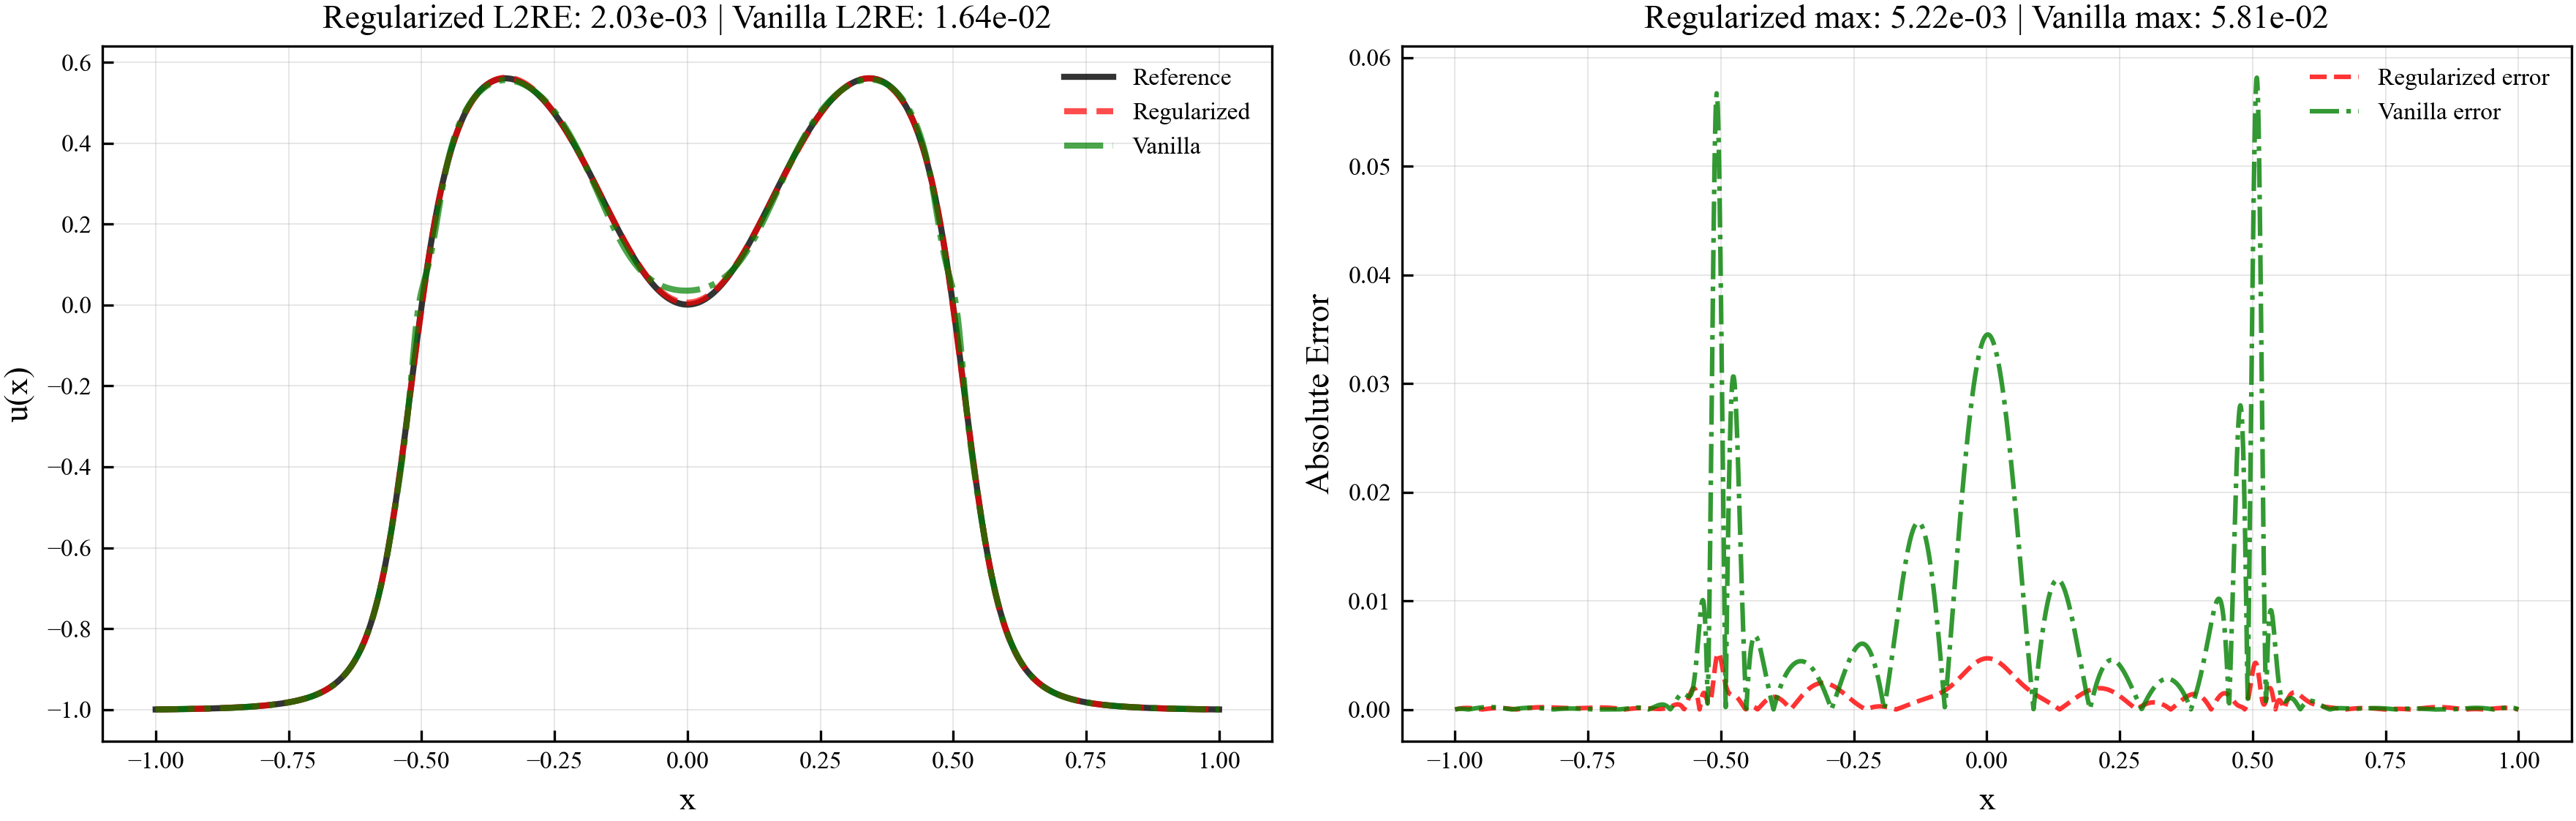

In [26]:
allen_cahn_predictions = []
for dir in ["allen-cahn_None_lambda_0.0", "allen-cahn_L1_lambda_1e-05"]:
  solver = results_allen_cahn[0]["solver"]
  solver = load_nets(f"./final_model_states/david_finall/allen-cahn_52/{dir}/solution_epoch_5300.pt", solver, load_best_nets=True)[0]
  sol = solver.get_solution()
  u_pred = sol(x, t_1d, r)
  allen_cahn_predictions.append(u_pred)

plot_1d_solution_comparison_few(
    x,
    u_ref_allen_cahn,
    allen_cahn_predictions[1],
    allen_cahn_predictions[0],
    filename=f"allen_cahn_baselilne_regular_vanilla_comparison",
    save_dir="./final_plots/allen_cahn"
)


#### Burgers

In [27]:
local_head = 0
dt = 0.001
r_i = 0.01/np.pi
t_i = 0.5

x = torch.arange(
    0, 1 + dt, dt, requires_grad=True, device=device if "device" in globals() else None
)
t_1d = torch.full_like(x, t_i, requires_grad=True, device=x.device)
r = torch.full_like(x, r_i, requires_grad=True, device=x.device)

_, _, u_ref_burgers = solve_burgers(r_i, 1e-4, t_i, 0, 0, 1.0, dt)

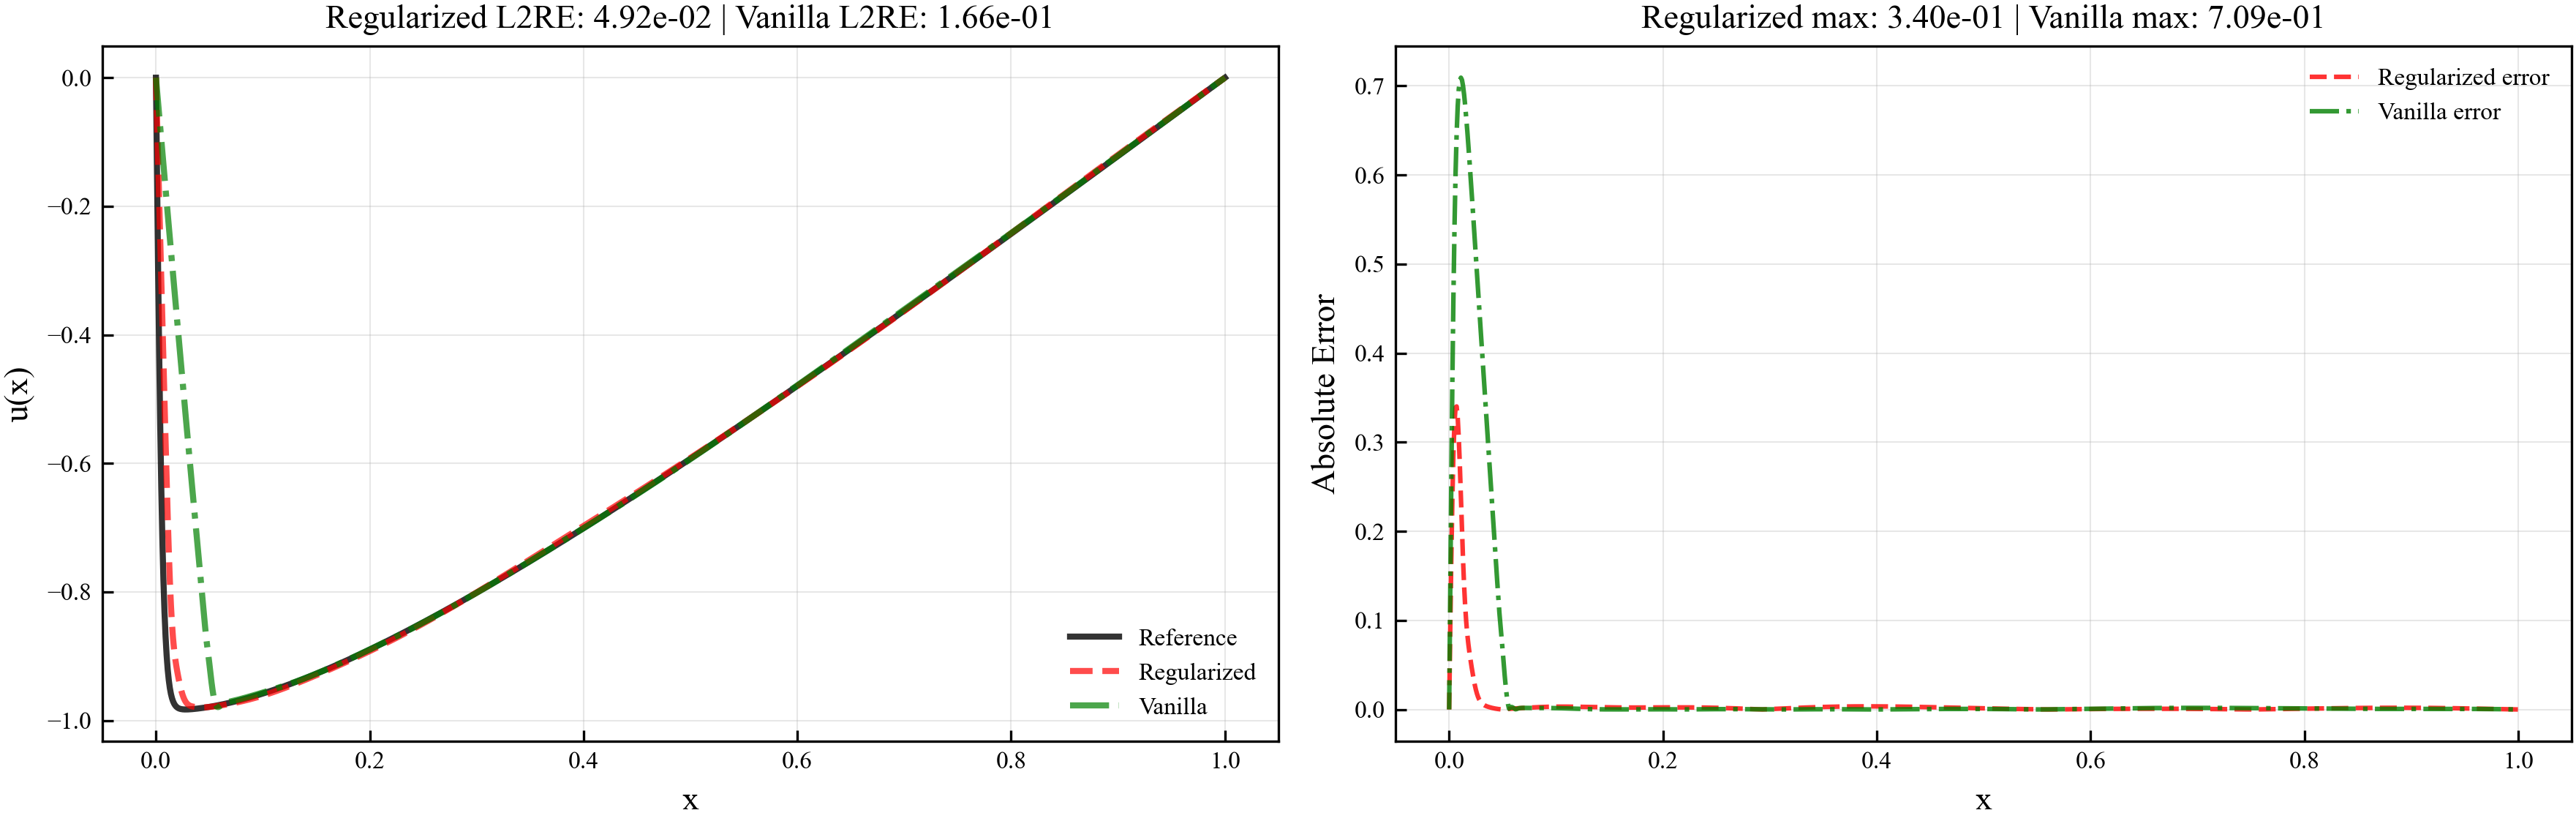

In [28]:
burgers_predictions = []
for dir in ["burgers_None_lambda_0.0", "burgers_J_lambda_0.1"]:
  solver = results_burgers[0]["solver"]
  load_path = f"./final_model_states/david_finall/burgers_52/{dir}/solution_epoch_5300.pt"
  solver = load_nets(load_path, solver, load_best_nets=True)[0]
  sol = solver.get_solution()
  u_pred = sol(x, t_1d, r)
  burgers_predictions.append(u_pred)

plot_1d_solution_comparison_few(
    x,
    u_ref_burgers,
    burgers_predictions[1],
    burgers_predictions[0],
    filename=f"burgers_baselilne_regular_vanilla_comparison",
    save_dir="./final_plots/burgers"
)

#### Fisher


In [29]:
local_head = 0
dt = 0.001
r_i = 0.1
t_i = 0.5

x = torch.arange(
    0, 1 + dt, dt, requires_grad=True, device=device if "device" in globals() else None
)
t_1d = torch.full_like(x, t_i, requires_grad=True, device=x.device)
r = torch.full_like(x, r_i, requires_grad=True, device=x.device)

_, _, u_ref_fisher = solve_fisher_kpp(r_i, 1e-4, t_i, 0, 0, 1.0, dt)

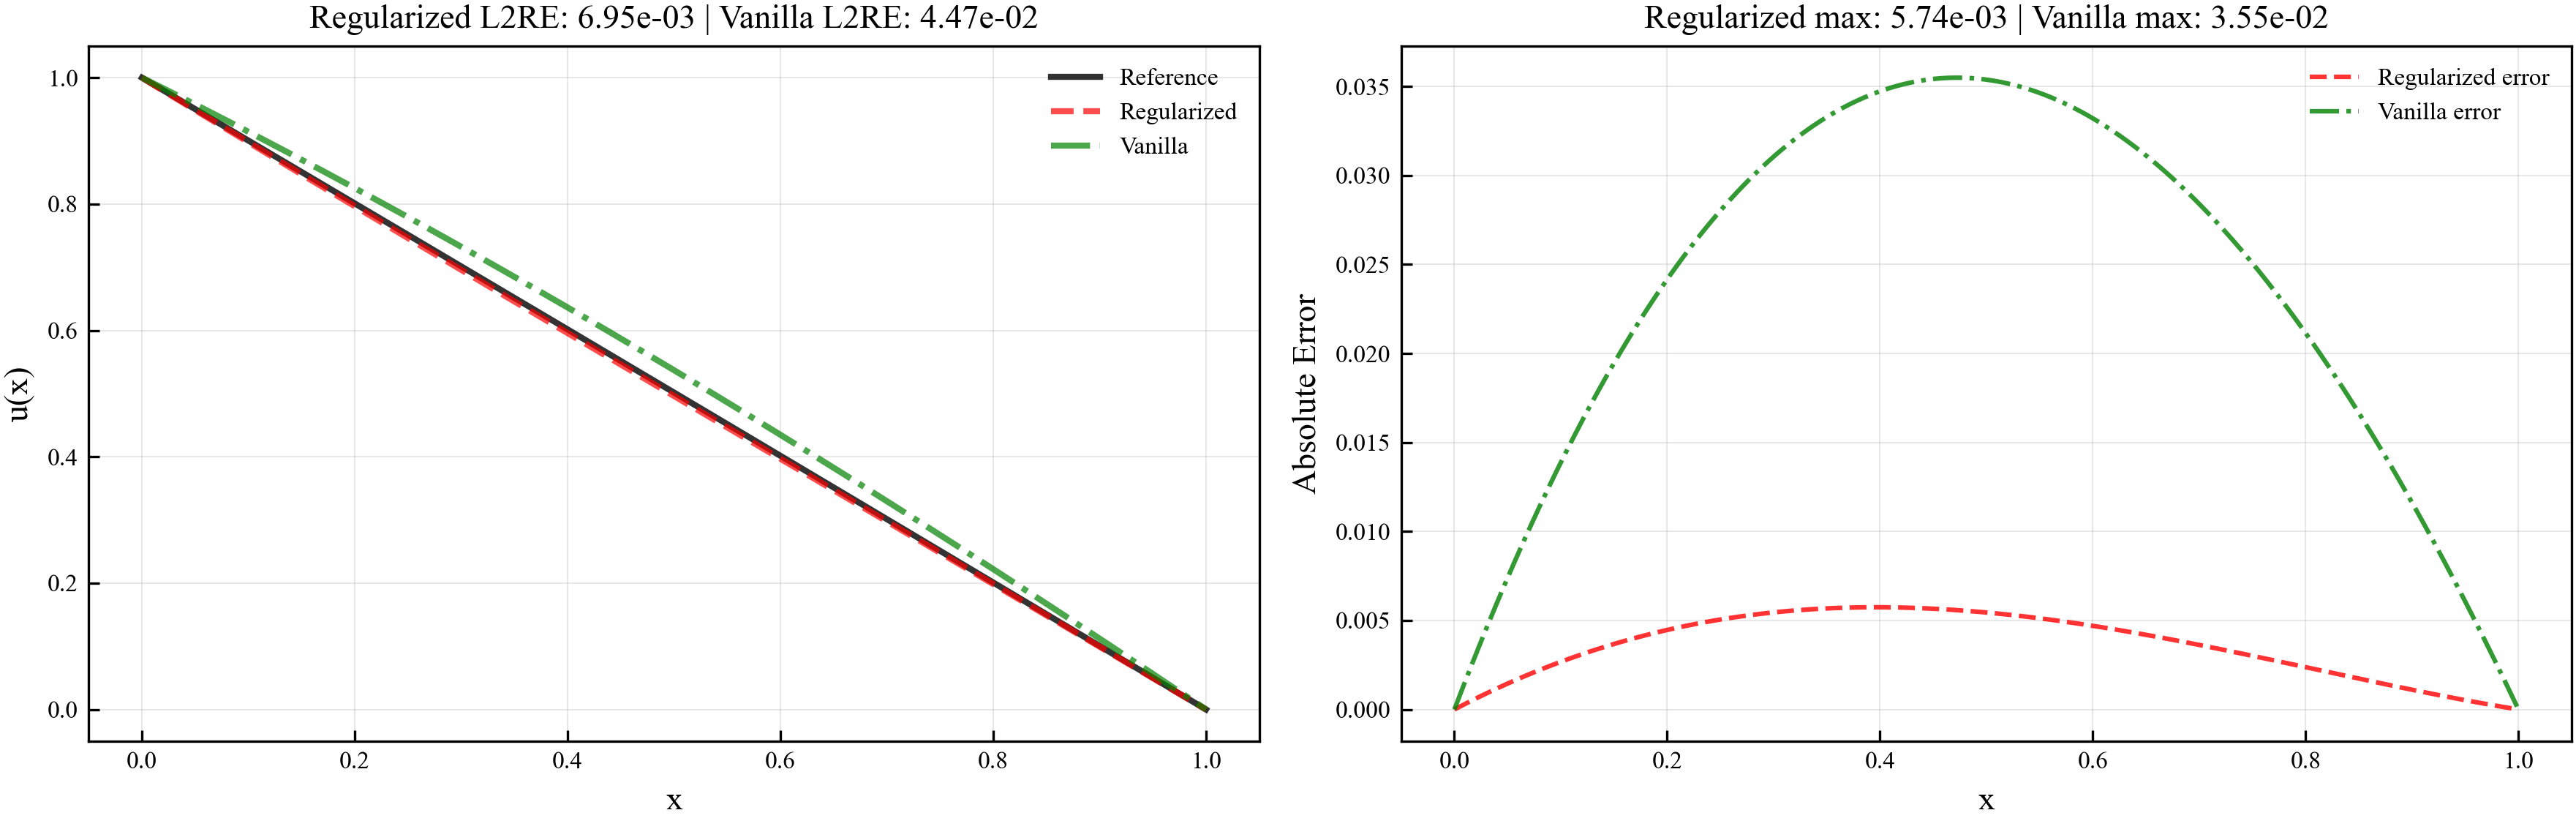

In [30]:
fisher_predictions = []
for dir in ["fisher_None_lambda_0.0", "fisher_UR_lambda_1e-06"]:
  solver = results_fisher[0]["solver"]
  load_path = f"./final_model_states/david_finall/fisher_52/{dir}/solution_epoch_5300.pt"
  solver = load_nets(load_path, solver, load_best_nets=True)[0]
  sol = solver.get_solution()
  u_pred = sol(x, t_1d, r)
  fisher_predictions.append(u_pred)

plot_1d_solution_comparison_few(
    x,
    u_ref_fisher,
    fisher_predictions[1],
    fisher_predictions[0],
    filename=f"fisher_baselilne_regular_vanilla_comparison",
    save_dir="./final_plots/fisher"

)